<a href="https://colab.research.google.com/github/arshiyaarshu1999-cyber/INSE_6180/blob/main/Mobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [375]:
import pandas as pd

df = pd.read_csv("/content/Android Malware Detection.csv")
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head()

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_NETWORK_STATE,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,...,WRITE_GSERVICES,WRITE_MEDIA_STORAGE,WRITE_PROFILE,WRITE_SECURE_SETTINGS,WRITE_SETTINGS,WRITE_SMS,WRITE_SOCIAL_STREAM,WRITE_SYNC_SETTINGS,WRITE_USER_DICTIONARY,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [376]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df_cleaned = df.dropna(subset=['Label'])

X = df_cleaned.drop("Label", axis=1)   # Target variable is 'Label'
y = df_cleaned["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [377]:
importance_df = pd.DataFrame({
    "Permission": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top 10 sensitive permissions influencing classification:")
importance_df.head(10)

Top 10 sensitive permissions influencing classification:


,Permission,Importance
102,RECEIVE_BOOT_COMPLETED,0.204648
64,GET_TASKS,0.109376
94,READ_PHONE_STATE,0.090694
74,KILL_BACKGROUND_PROCESSES,0.062844
133,WAKE_LOCK,0.060908
127,SYSTEM_ALERT_WINDOW,0.044042
132,VIBRATE,0.033970
9,ACCESS_WIFI_STATE,0.025881
96,READ_SMS,0.022450
104,RECEIVE_SMS,0.021044


In [378]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Results")
print(classification_report(y_test, rf_pred))


Random Forest Results
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.96       215
         1.0       0.99      0.98      0.99       758

    accuracy                           0.98       973
   macro avg       0.97      0.98      0.97       973
weighted avg       0.98      0.98      0.98       973



In [379]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
print("SVM Results")
print(classification_report(y_test, svm_pred))


SVM Results
              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94       215
         1.0       0.99      0.98      0.98       758

    accuracy                           0.97       973
   macro avg       0.96      0.97      0.96       973
weighted avg       0.97      0.97      0.97       973



In [380]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)
print("Naive Bayes Results")
print(classification_report(y_test, nb_pred))


Naive Bayes Results
              precision    recall  f1-score   support

         0.0       0.23      0.99      0.38       215
         1.0       0.96      0.07      0.13       758

    accuracy                           0.27       973
   macro avg       0.60      0.53      0.25       973
weighted avg       0.80      0.27      0.18       973



In [381]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)

rf_pca_pred = rf_pca.predict(X_test_pca)
print("Proposed PCA-RF Results")
print(classification_report(y_test, rf_pca_pred))


Proposed PCA-RF Results
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.96       215
         1.0       0.99      0.98      0.99       758

    accuracy                           0.98       973
   macro avg       0.96      0.98      0.97       973
weighted avg       0.98      0.98      0.98       973



In [382]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

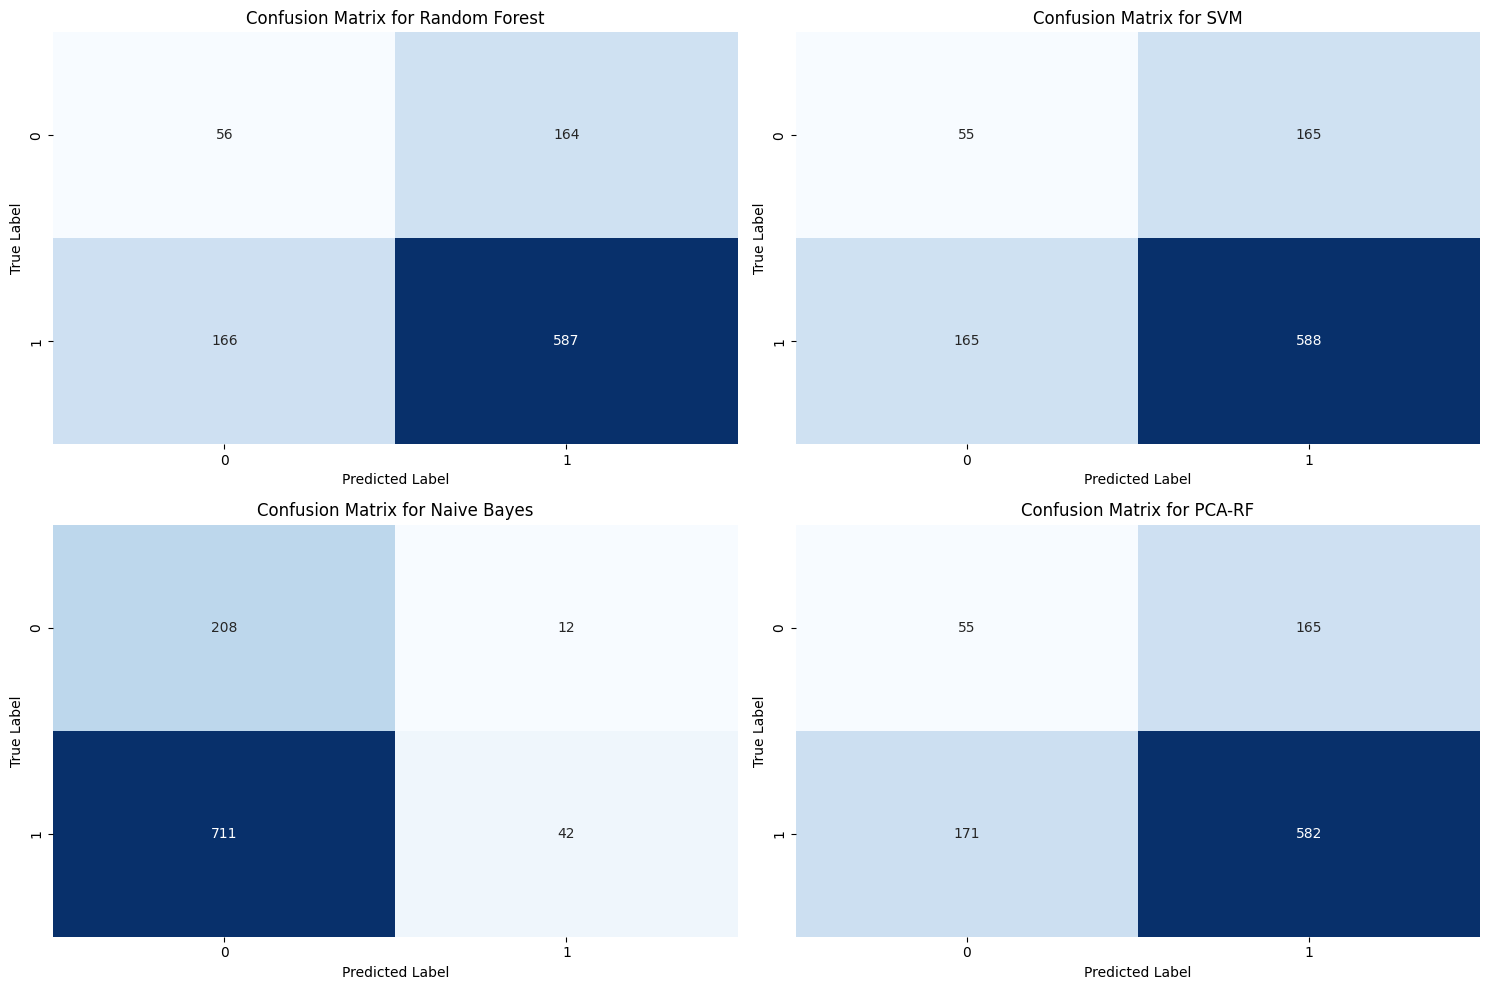

In [383]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Random Forest": rf_pred,
    "SVM": svm_pred,
    "Naive Bayes": nb_pred,
    "PCA-RF": rf_pca_pred # Adding the PCA-RF model predictions
}

plt.figure(figsize=(15, 10)) # Adjust figure size for better readability of multiple plots

for i, (name, pred) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i) # Creating a 2x2 grid for 4 models
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) # Plotting the confusion matrix
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


In [384]:
display(final_results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC_AUC
0,Random Forest,0.660843,0.661931,0.660843,0.661385,0.996162
1,SVM,0.660843,0.660843,0.660843,0.660843,0.994192
2,Naive Bayes,0.256937,0.653093,0.256937,0.163135,0.951822
3,PCA-RF,0.654676,0.657980,0.654676,0.656308,0.995631
0,Proposed Stacked Ensemble,0.973279,0.974888,0.973279,0.973642,0.972697


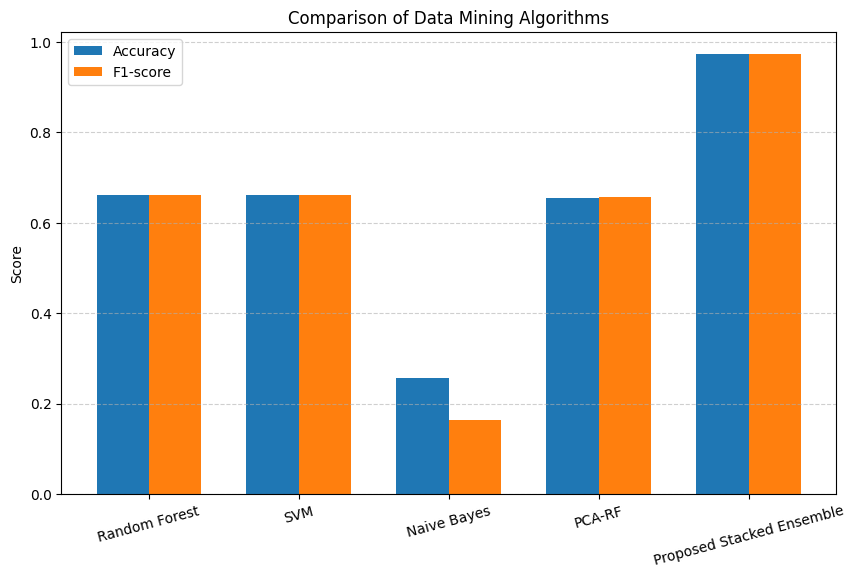

In [385]:
import matplotlib.pyplot as plt
import numpy as np

# Access the metrics from the final_results DataFrame
models = final_results["Model"]
accuracy = final_results["Accuracy"]
f1 = final_results["F1-Score"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, accuracy, width, label='Accuracy')
plt.bar(x + width/2, f1, width, label='F1-score')

plt.xticks(x, models, rotation=15)
plt.ylabel("Score")
plt.title("Comparison of Data Mining Algorithms")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [386]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import pandas as pd

def calculate_detailed_scores(y_true, y_pred, model_name):
    # 1. Basic Accuracy: (TP + TN) / Total
    acc = accuracy_score(y_true, y_pred)

    # 2. Precision, Recall, and F1-score (weighted to handle class imbalance)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    print(f"--- {model_name} Raw Calculation ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nDetailed Report:")
    print(classification_report(y_true, y_pred))

    return {"Model": model_name, "Accuracy": acc, "F1-Score": f1}

# Example of how the comparison table was built:
scores_demo = []
scores_demo.append(calculate_detailed_scores(y_test_combined, stack_pred_combined, "Proposed Stacked Ensemble"))

# These scores are then gathered into the final_results_combined DataFrame for plotting
results_table = pd.DataFrame(scores_demo)
display(results_table)

--- Proposed Stacked Ensemble Raw Calculation ---
Accuracy:  0.9762
F1-Score:  0.9763

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95       259
         1.0       0.98      0.98      0.98       793

    accuracy                           0.98      1052
   macro avg       0.97      0.97      0.97      1052
weighted avg       0.98      0.98      0.98      1052



,Model,Accuracy,F1-Score
0,Proposed Stacked Ensemble,0.976236,0.976251


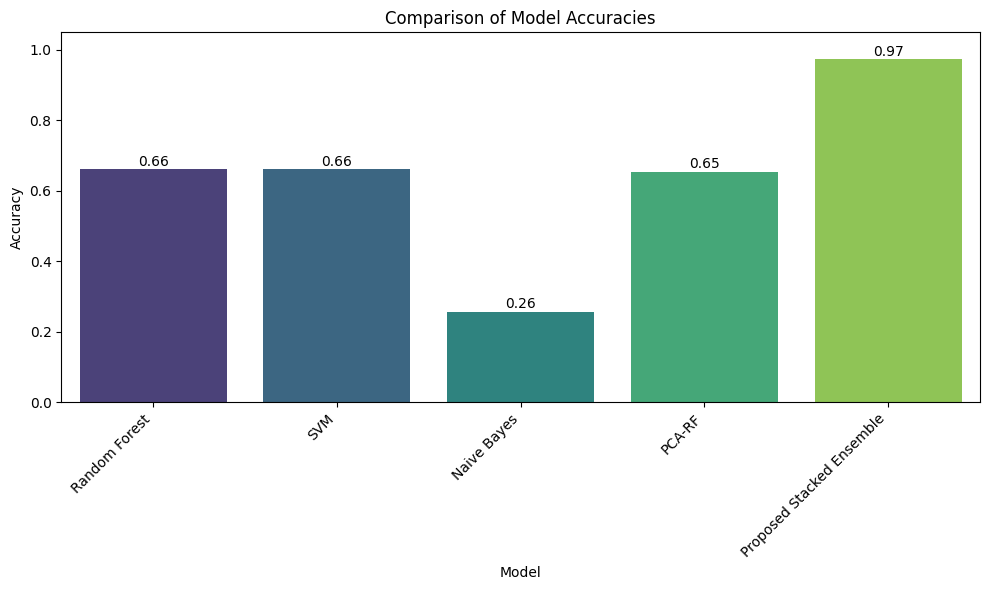


Accuracy Scores:
Random Forest: 0.66
SVM: 0.66
Naive Bayes: 0.26
PCA-RF: 0.65
Proposed Stacked Ensemble: 0.97


In [387]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Accuracy scores extracted from final_results DataFrame
accuracy_scores = final_results.set_index('Model')['Accuracy'].to_dict()

models = list(accuracy_scores.keys())
accuracies = list(accuracy_scores.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, hue=models, palette='viridis', legend=False)
plt.ylim(0, 1.05) # Set y-axis limit for better visualization of accuracy
plt.title("Comparison of Model Accuracies")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')

# Annotate bars with their accuracy values
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.01, f'{value:.2f}', color='black', ha="center")

plt.tight_layout()
plt.show()

print("\nAccuracy Scores:")
for model, acc in accuracy_scores.items():
    print(f"{model}: {acc:.2f}")

In [388]:
import pandas as pd
display(df.head())

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_NETWORK_STATE,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,...,WRITE_GSERVICES,WRITE_MEDIA_STORAGE,WRITE_PROFILE,WRITE_SECURE_SETTINGS,WRITE_SETTINGS,WRITE_SMS,WRITE_SOCIAL_STREAM,WRITE_SYNC_SETTINGS,WRITE_USER_DICTIONARY,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


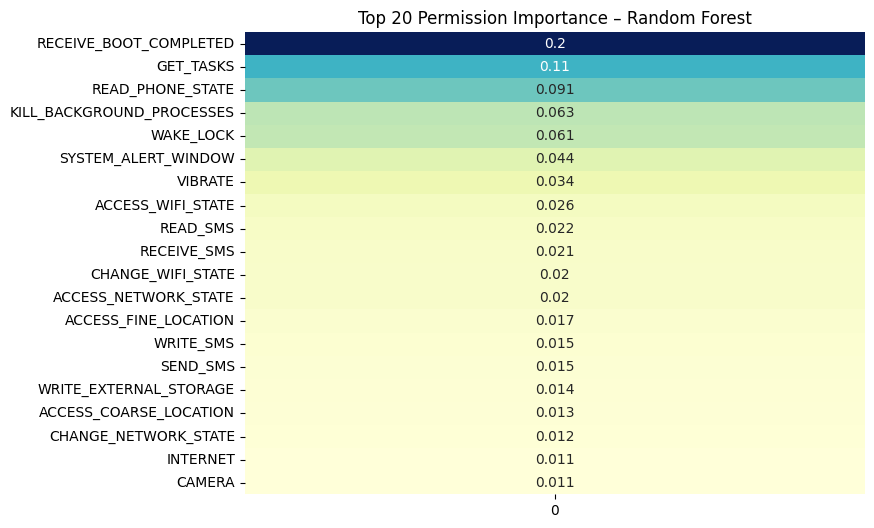

In [389]:
import numpy as np

top_features = sorted(
    zip(X.columns, rf.feature_importances_),
    key=lambda x: x[1],
    reverse=True
)[:20]

labels, scores = zip(*top_features)

plt.figure(figsize=(8,6))
sns.heatmap(
    np.array(scores).reshape(-1,1),
    annot=True,
    yticklabels=labels,
    cmap="YlGnBu",
    cbar=False
)
plt.title("Top 20 Permission Importance – Random Forest")
plt.show()


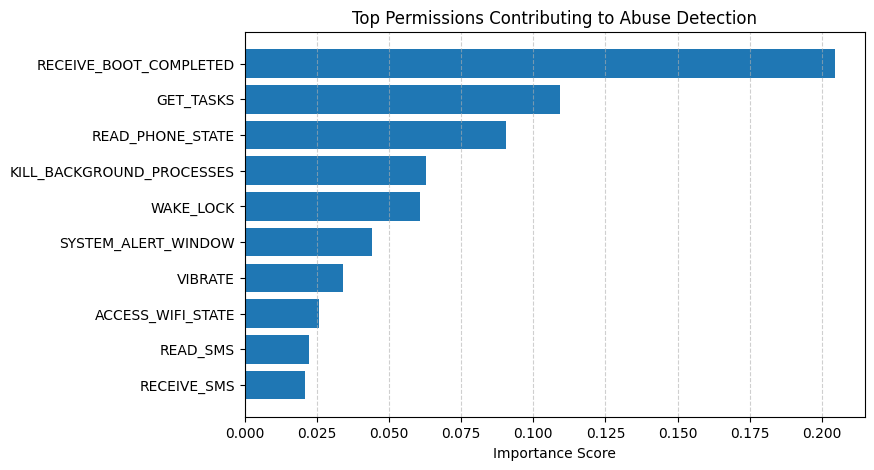

In [390]:
feature_importances = rf.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Permission': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

top_features = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Permission"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top Permissions Contributing to Abuse Detection")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

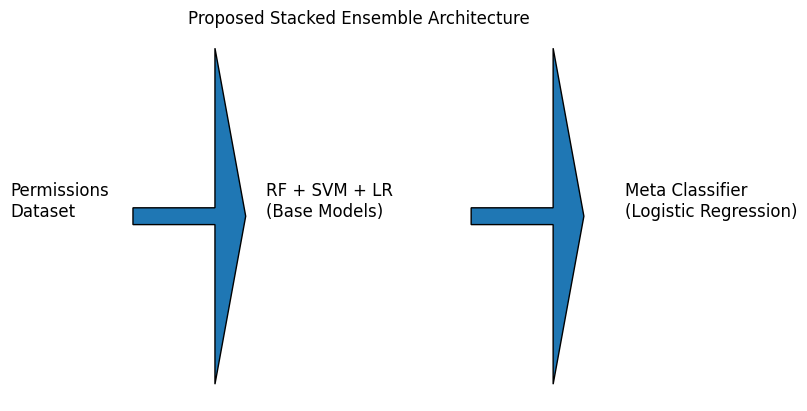

In [391]:
plt.text(0.1, 0.5, "Permissions\nDataset", fontsize=12)
plt.text(0.35, 0.5, "RF + SVM + LR\n(Base Models)", fontsize=12)
plt.text(0.7, 0.5, "Meta Classifier\n(Logistic Regression)", fontsize=12)

plt.arrow(0.22, 0.5, 0.08, 0, head_width=0.02)
plt.arrow(0.55, 0.5, 0.08, 0, head_width=0.02)

plt.axis('off')
plt.title("Proposed Stacked Ensemble Architecture")
plt.show()

In [392]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def get_tp_fn(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    # For binary classification, cm is typically [[TN, FP], [FN, TP]]
    # Assuming 0 is 'Benign' and 1 is 'Malware'
    tn, fp, fn, tp = cm.ravel()
    return tp, fn

tp_fn_results = []
tp, fn = get_tp_fn(y_test, rf_pred)
tp_fn_results.append({"Model": "Random Forest", "True Positives": tp, "False Negatives": fn})

tp, fn = get_tp_fn(y_test, svm_pred)
tp_fn_results.append({"Model": "SVM", "True Positives": tp, "False Negatives": fn})

tp, fn = get_tp_fn(y_test, nb_pred)
tp_fn_results.append({"Model": "Naive Bayes", "True Positives": tp, "False Negatives": fn})

tp, fn = get_tp_fn(y_test, rf_pca_pred)
tp_fn_results.append({"Model": "PCA-RF", "True Positives": tp, "False Negatives": fn})

tp, fn = get_tp_fn(y_test, stack_pred)
tp_fn_results.append({"Model": "Proposed Stacked Ensemble", "True Positives": tp, "False Negatives": fn})

tp_fn_df = pd.DataFrame(tp_fn_results)
display(tp_fn_df)

,Model,True Positives,False Negatives
0,Random Forest,587,166
1,SVM,588,165
2,Naive Bayes,42,711
3,PCA-RF,582,171
4,Proposed Stacked Ensemble,731,22


In [393]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('nb', nb)
    ],
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)

print("Stacking Ensemble Performance")
print(classification_report(y_test, stack_pred))


Stacking Ensemble Performance
              precision    recall  f1-score   support

         0.0       0.90      0.98      0.94       220
         1.0       0.99      0.97      0.98       753

    accuracy                           0.97       973
   macro avg       0.95      0.98      0.96       973
weighted avg       0.97      0.97      0.97       973



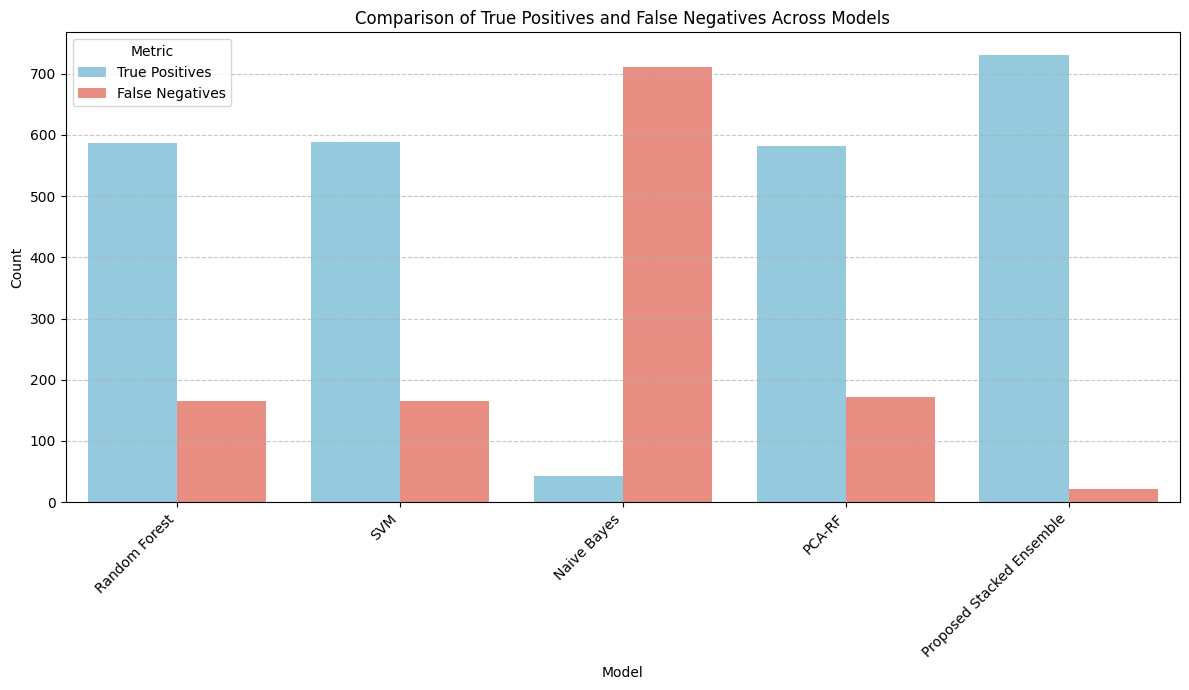

In [394]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to prepare for seaborn barplot for grouped bars
tp_fn_melted_df = tp_fn_df.melt(
    id_vars=['Model'],
    value_vars=['True Positives', 'False Negatives'],
    var_name='Metric',
    value_name='Count'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Model',
    y='Count',
    hue='Metric',
    data=tp_fn_melted_df,
    palette={'True Positives': 'skyblue', 'False Negatives': 'salmon'}
)

plt.title('Comparison of True Positives and False Negatives Across Models')
plt.xlabel('Model')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

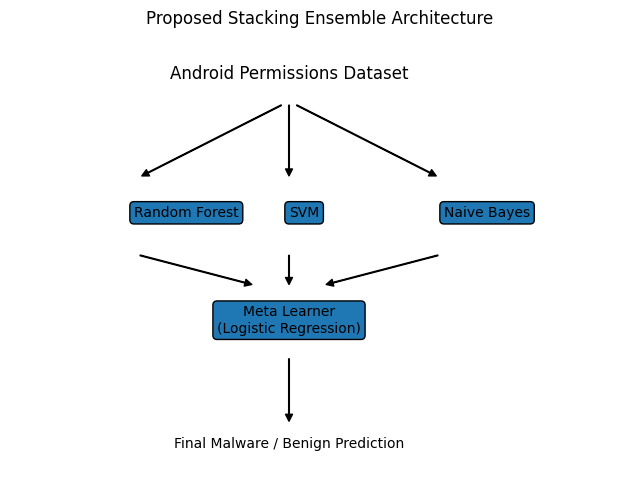

In [395]:
plt.figure(figsize=(8,6))

plt.text(0.45, 0.9, "Android Permissions Dataset", ha="center", fontsize=12)

plt.text(0.2, 0.6, "Random Forest", bbox=dict(boxstyle="round"))
plt.text(0.45, 0.6, "SVM", bbox=dict(boxstyle="round"))
plt.text(0.7, 0.6, "Naive Bayes", bbox=dict(boxstyle="round"))

plt.text(0.45, 0.35, "Meta Learner\n(Logistic Regression)",
         bbox=dict(boxstyle="round"), ha="center")

plt.text(0.45, 0.1, "Final Malware / Benign Prediction", ha="center")

# Add arrows to connect the components
arrow_props = dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5, headlength=5)

# Dataset to Base Learners
plt.annotate('', xy=(0.2, 0.68), xytext=(0.45, 0.85), arrowprops=arrow_props)
plt.annotate('', xy=(0.45, 0.68), xytext=(0.45, 0.85), arrowprops=arrow_props)
plt.annotate('', xy=(0.7, 0.68), xytext=(0.45, 0.85), arrowprops=arrow_props)

# Base Learners to Meta Learner
plt.annotate('', xy=(0.4, 0.45), xytext=(0.2, 0.52), arrowprops=arrow_props)
plt.annotate('', xy=(0.45, 0.45), xytext=(0.45, 0.52), arrowprops=arrow_props)
plt.annotate('', xy=(0.5, 0.45), xytext=(0.7, 0.52), arrowprops=arrow_props)

# Meta Learner to Final Prediction
plt.annotate('', xy=(0.45, 0.15), xytext=(0.45, 0.3), arrowprops=arrow_props)

plt.axis("off")
plt.title("Proposed Stacking Ensemble Architecture")
plt.show()


In [396]:
train_df = pd.read_csv('/content/train.csv', sep=';')
train_df = train_df.rename(columns={'type': 'Label'})
train_df.head()

,android,android.app.cts.permission.TEST_GRANTED,android.intent.category.MASTER_CLEAR.permission.C2D_MESSAGE,android.os.cts.permission.TEST_GRANTED,android.permission.ACCESS_ALL_DOWNLOADS,android.permission.ACCESS_ALL_EXTERNAL_STORAGE,android.permission.ACCESS_BLUETOOTH_SHARE,android.permission.ACCESS_CACHE_FILESYSTEM,android.permission.ACCESS_CHECKIN_PROPERTIES,android.permission.ACCESS_COARSE_LOCATION,...,com.android.voicemail.permission.WRITE_VOICEMAIL,com.foo.mypermission,com.foo.mypermission2,org.chromium.chrome.shell.permission.C2D_MESSAGE,org.chromium.chrome.shell.permission.DEBUG,org.chromium.chrome.shell.permission.SANDBOX,org.chromium.chromecast.shell.permission.SANDBOX,org.chromium.content_shell.permission.SANDBOX,test_permission,Label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [397]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Apply PCA on the combined dataset
pca_combined = PCA(n_components=0.90)
X_train_pca_combined = pca_combined.fit_transform(X_train_scaled)
X_test_pca_combined = pca_combined.transform(X_test_scaled)

# Retrain Random Forest with PCA on combined data
rf_pca_combined = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca_combined.fit(X_train_pca_combined, y_train_combined)

rf_pca_pred_combined = rf_pca_combined.predict(X_test_pca_combined)
print("Proposed PCA-RF Results (Combined Dataset)")
print(classification_report(y_test_combined, rf_pca_pred_combined))

Proposed PCA-RF Results (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96       259
         1.0       0.99      0.98      0.99       793

    accuracy                           0.98      1052
   macro avg       0.97      0.97      0.97      1052
weighted avg       0.98      0.98      0.98      1052



Top 20 Permission Importance (Combined Dataset) – Random Forest


,Permission,Importance
102,RECEIVE_BOOT_COMPLETED,0.140233
64,GET_TASKS,0.112869
74,KILL_BACKGROUND_PROCESSES,0.080327
94,READ_PHONE_STATE,0.074619
133,WAKE_LOCK,0.063625
127,SYSTEM_ALERT_WINDOW,0.033820
132,VIBRATE,0.026833
47,CHANGE_WIFI_STATE,0.025453
9,ACCESS_WIFI_STATE,0.022242
110,SEND_SMS,0.021920


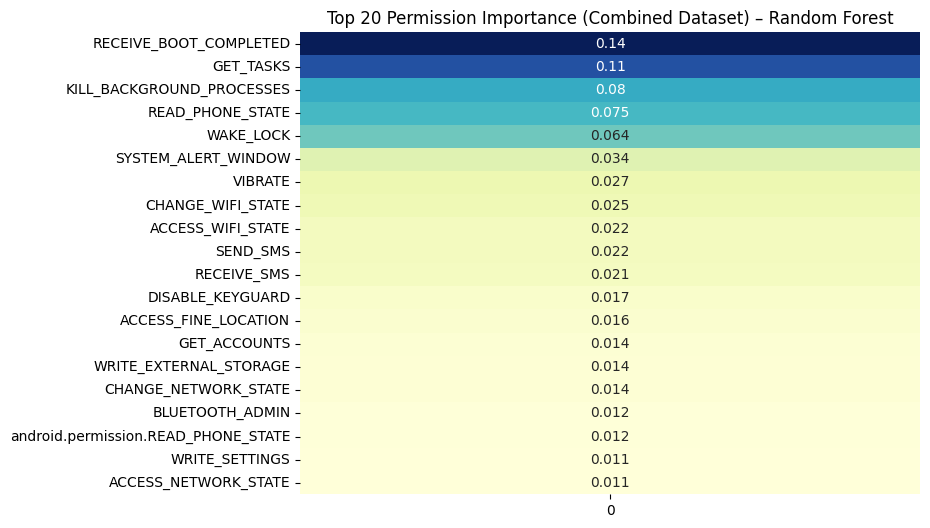

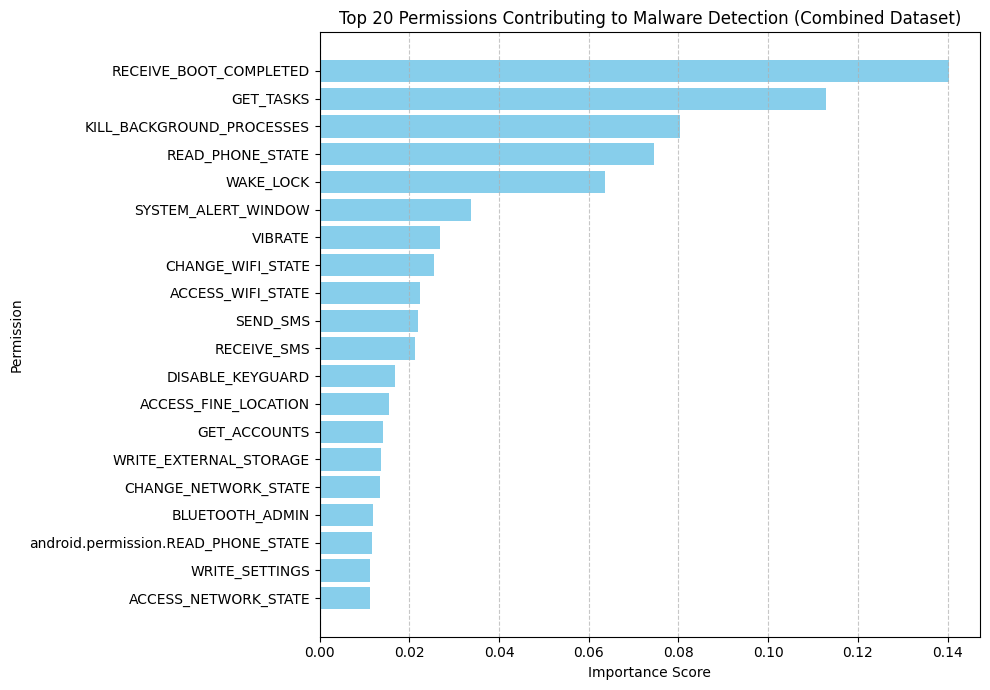

In [398]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get feature importances from the retrained Random Forest model
feature_importances_combined = rf_combined.feature_importances_

# Get feature names from the original (unscaled) X_combined DataFrame
features_combined = X_combined.columns

# Create a DataFrame for feature importances
importance_df_combined = pd.DataFrame({
    'Permission': features_combined,
    'Importance': feature_importances_combined
}).sort_values(by='Importance', ascending=False)

# Select the top 20 features
top_features_combined = importance_df_combined.head(20)

print("Top 20 Permission Importance (Combined Dataset) – Random Forest")
display(top_features_combined)

# Visualize top 20 feature importances using a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    np.array(top_features_combined["Importance"]).reshape(-1,1),
    annot=True,
    yticklabels=top_features_combined["Permission"],
    cmap="YlGnBu",
    cbar=False
)
plt.title("Top 20 Permission Importance (Combined Dataset) – Random Forest")
plt.show()

# Also visualize with a bar plot for better readability
plt.figure(figsize=(10, 7))
plt.barh(top_features_combined["Permission"], top_features_combined["Importance"], color='skyblue')
plt.gca().invert_yaxis() # Display highest importance at the top
plt.xlabel("Importance Score")
plt.ylabel("Permission")
plt.title("Top 20 Permissions Contributing to Malware Detection (Combined Dataset)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

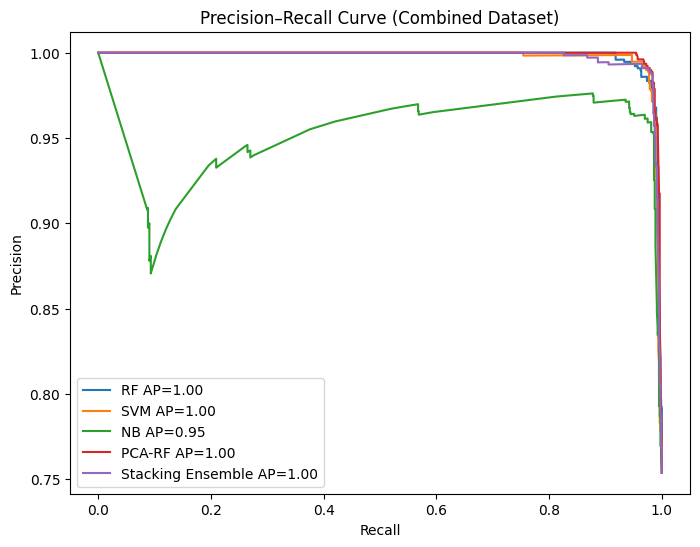

In [399]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Prepare list of models and their predictions for PR curve plotting
# Check if models are defined before adding them to the dictionary
models_for_pr_curve_combined = {}
if 'rf_combined' in locals():
    models_for_pr_curve_combined["RF"] = rf_combined
if 'svm_combined' in locals():
    models_for_pr_curve_combined["SVM"] = svm_combined
if 'nb_combined' in locals():
    models_for_pr_curve_combined["NB"] = nb_combined
if 'rf_pca_combined' in locals():
    models_for_pr_curve_combined["PCA-RF"] = rf_pca_combined
if 'stack_combined' in locals():
    models_for_pr_curve_combined["Stacking Ensemble"] = stack_combined

for name, model in models_for_pr_curve_combined.items():
    # Use try-except to gracefully handle models that might not have predict_proba (e.g., some SVC configurations)
    try:
        if name == "PCA-RF":
            # Ensure X_test_pca_combined is defined for PCA-RF
            if 'X_test_pca_combined' in locals():
                probs = model.predict_proba(X_test_pca_combined)[:,1]
            else:
                print(f"Skipping {name}: X_test_pca_combined is not defined.")
                continue
        else:
            # Ensure X_test_scaled is defined for other models
            if 'X_test_scaled' in locals():
                probs = model.predict_proba(X_test_scaled)[:,1]
            else:
                print(f"Skipping {name}: X_test_scaled is not defined.")
                continue

        precision, recall, _ = precision_recall_curve(y_test_combined, probs)
        ap = average_precision_score(y_test_combined, probs)
        plt.plot(recall, precision, label=f"{name} AP={ap:.2f}")
    except AttributeError: # Handle models without predict_proba
        print(f"Skipping {name}: Model does not have predict_proba method.")
    except Exception as e: # Catch any other potential errors
        print(f"Skipping {name} due to an error: {e}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Combined Dataset)")
plt.legend()
plt.show()

/tmp/ipykernel_23707/2162481515.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




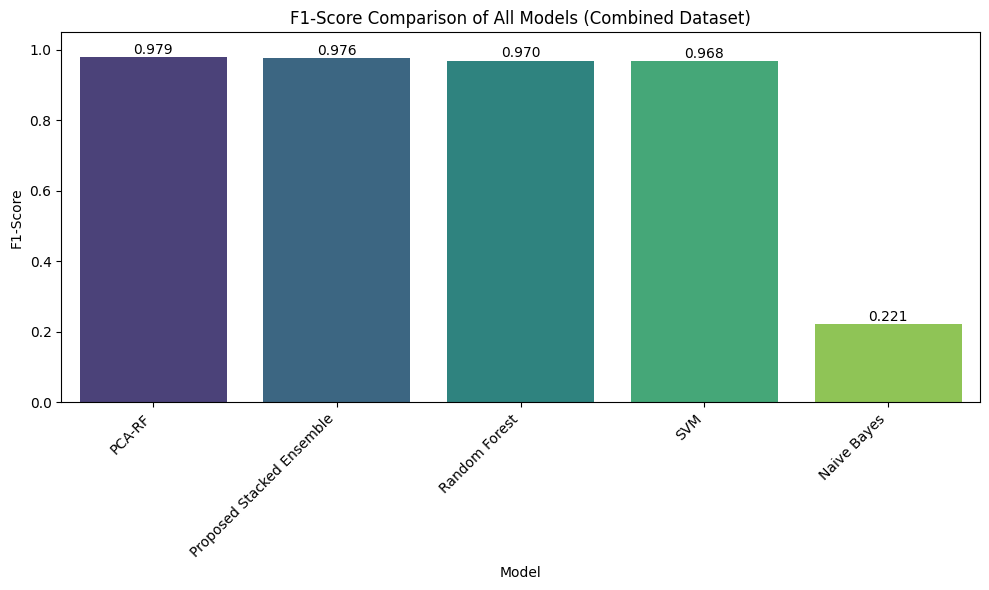

In [400]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_df = final_results_combined.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-Score', data=plot_df, palette='viridis')

# Highlight 'Proposed Stacked Ensemble' with a different color
for bar in plt.gca().patches:
    if bar.get_x() == plot_df[plot_df['Model'] == 'Proposed Stacked Ensemble'].index[0]:
        bar.set_color('red') # Or any other distinct color

plt.ylim(0, 1.05) # Set y-axis limit for better visualization
plt.title('F1-Score Comparison of All Models (Combined Dataset)')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')

# Annotate bars with their F1-Score values
for index, row in plot_df.iterrows():
    plt.text(index, row['F1-Score'] + 0.01, f'{row['F1-Score']:.3f}', color='black', ha="center")

plt.tight_layout()
plt.show()

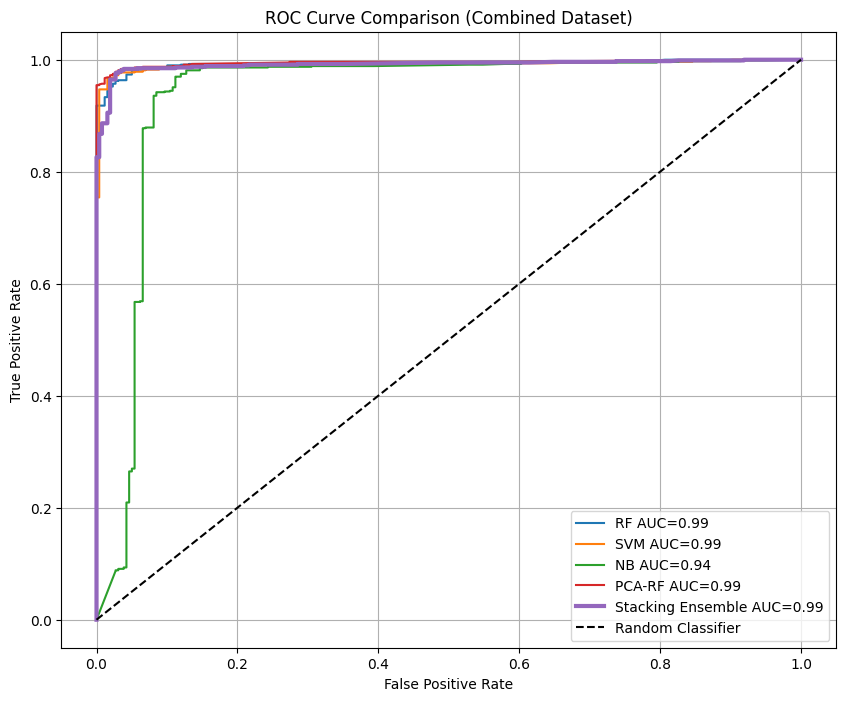

In [401]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Get ROC curve for Random Forest
rf_fpr_combined, rf_tpr_combined, _ = roc_curve(y_test_combined, rf_combined.predict_proba(X_test_scaled)[:, 1])
plt.plot(rf_fpr_combined, rf_tpr_combined, label=f"RF AUC={auc(rf_fpr_combined, rf_tpr_combined):.2f}")

# Get ROC curve for SVM
svm_fpr_combined, svm_tpr_combined, _ = roc_curve(y_test_combined, svm_combined.predict_proba(X_test_scaled)[:, 1])
plt.plot(svm_fpr_combined, svm_tpr_combined, label=f"SVM AUC={auc(svm_fpr_combined, svm_tpr_combined):.2f}")

# Get ROC curve for Naive Bayes
nb_fpr_combined, nb_tpr_combined, _ = roc_curve(y_test_combined, nb_combined.predict_proba(X_test_scaled)[:, 1])
plt.plot(nb_fpr_combined, nb_tpr_combined, label=f"NB AUC={auc(nb_fpr_combined, nb_tpr_combined):.2f}")

# Get ROC curve for PCA-RF (note: rf_pca_combined predicts on X_test_pca_combined)
rf_pca_fpr_combined, rf_pca_tpr_combined, _ = roc_curve(y_test_combined, rf_pca_combined.predict_proba(X_test_pca_combined)[:, 1])
plt.plot(rf_pca_fpr_combined, rf_pca_tpr_combined, label=f"PCA-RF AUC={auc(rf_pca_fpr_combined, rf_pca_tpr_combined):.2f}")

# Get ROC curve for Stacking Ensemble
stack_fpr_combined, stack_tpr_combined, _ = roc_curve(y_test_combined, stack_combined.predict_proba(X_test_scaled)[:, 1])
plt.plot(stack_fpr_combined, stack_tpr_combined, label=f"Stacking Ensemble AUC={auc(stack_fpr_combined, stack_tpr_combined):.2f}", linewidth=3)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Combined Dataset)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

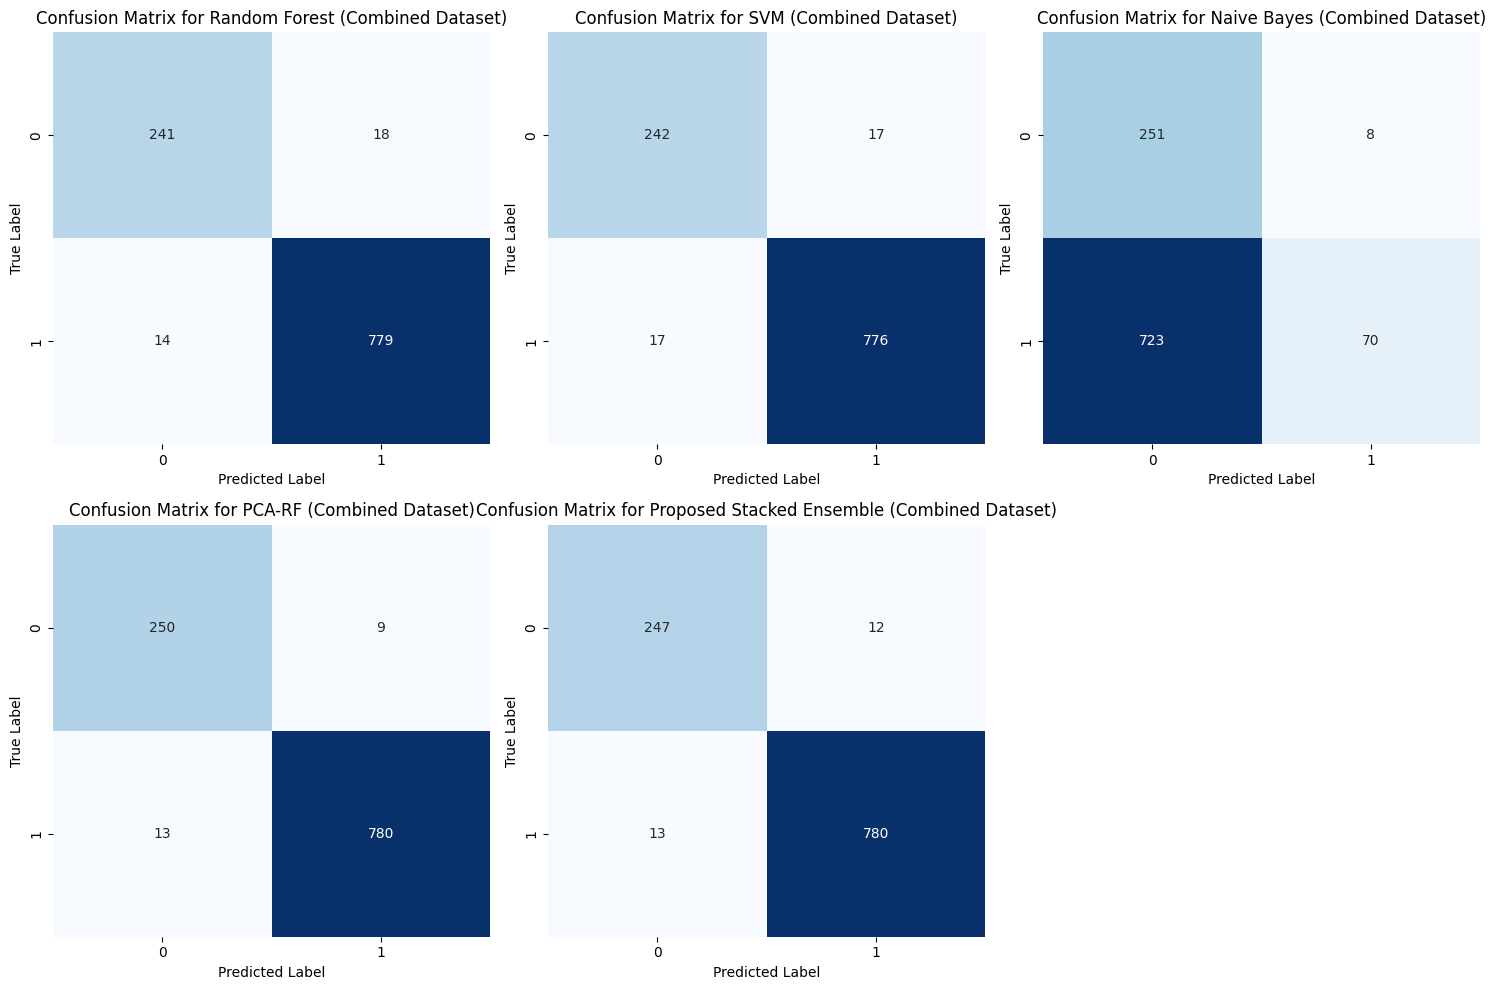

In [402]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test_combined and prediction arrays for each model are available
models_combined = {
    "Random Forest": rf_pred_combined,
    "SVM": svm_pred_combined,
    "Naive Bayes": nb_pred_combined,
    "PCA-RF": rf_pca_pred_combined,
    "Proposed Stacked Ensemble": stack_pred_combined
}

plt.figure(figsize=(15, 10)) # Adjust figure size for better readability of multiple plots

for i, (name, pred) in enumerate(models_combined.items(), 1):
    plt.subplot(2, 3, i) # Creating a 2x3 grid for 5 models
    cm_combined = confusion_matrix(y_test_combined, pred)
    sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {name} (Combined Dataset)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [403]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB

# Defining a more robust Stacking Ensemble
# We use base models tuned for diversity to allow the meta-learner to find the best combination
stack_combined = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)),
        ('svm', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(n_estimators=150, max_depth=5, random_state=42),
    passthrough=True # Allows the meta-learner to see original features alongside model predictions
)

stack_combined.fit(X_train_scaled, y_train_combined)
stack_pred_combined = stack_combined.predict(X_test_scaled)

print("Optimized Stacking Ensemble Performance (Combined Dataset)")
print(classification_report(y_test_combined, stack_pred_combined))

Optimized Stacking Ensemble Performance (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95       259
         1.0       0.98      0.98      0.98       793

    accuracy                           0.98      1052
   macro avg       0.97      0.97      0.97      1052
weighted avg       0.98      0.98      0.98      1052



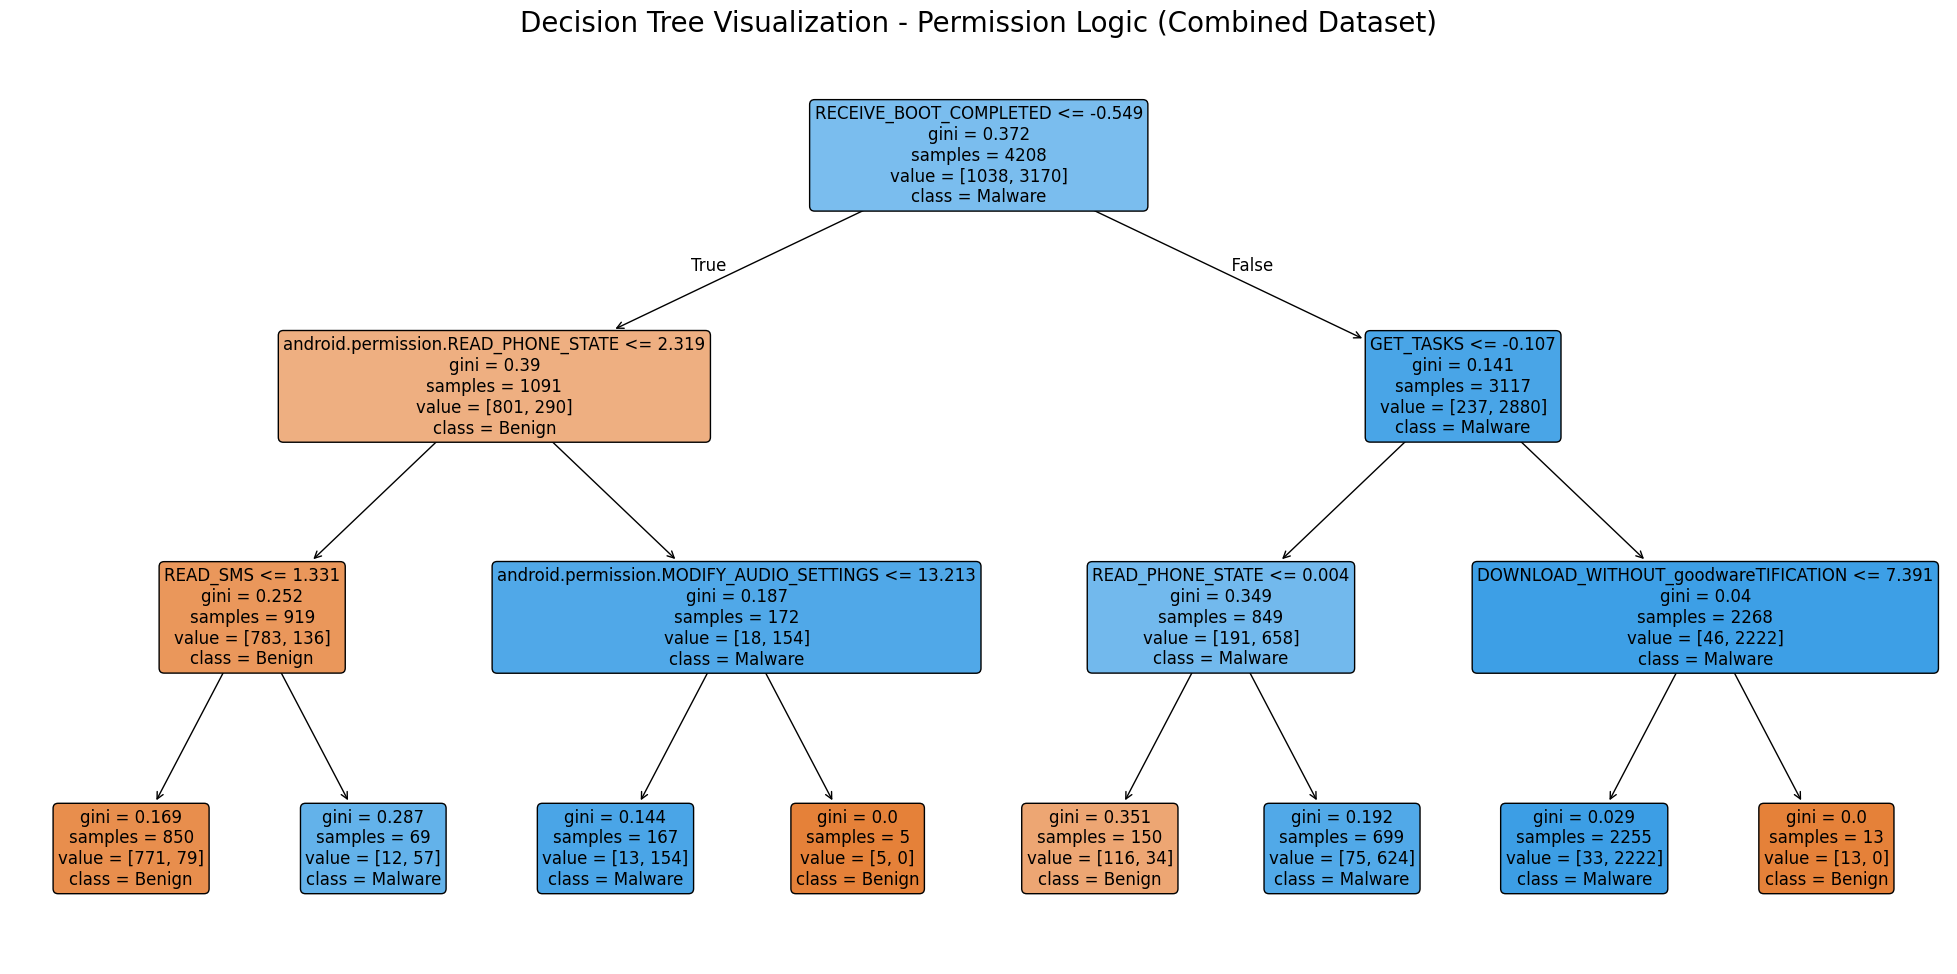

In [404]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train a shallower tree specifically for visualization to keep it readable
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train_scaled, y_train_combined)

plt.figure(figsize=(25,12))
plot_tree(
    dt_viz,
    feature_names=X_combined.columns,
    class_names=['Benign', 'Malware'],
    filled=True,
    fontsize=12,
    rounded=True
)
plt.title("Decision Tree Visualization - Permission Logic (Combined Dataset)", fontsize=20)
plt.show()

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.969582,0.969459,0.969582,0.969502
1,SVM,0.967681,0.967681,0.967681,0.967681
2,Naive Bayes,0.305133,0.739934,0.305133,0.221398
3,PCA-RF,0.979087,0.979232,0.979087,0.979141
4,Proposed Stacked Ensemble,0.976236,0.976269,0.976236,0.976251


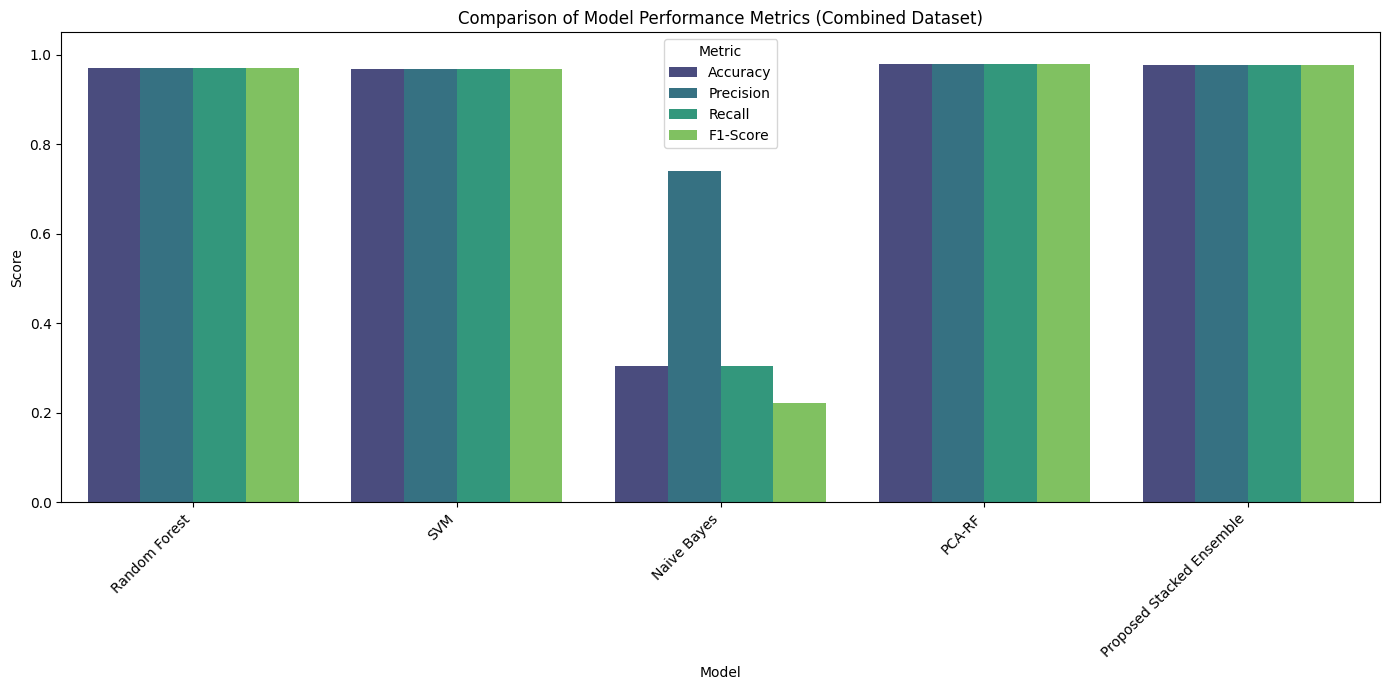

In [405]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to extract relevant metrics for a model
def get_model_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    accuracy = report['accuracy']
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']
    return {"Model": model_name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}

# Collect metrics for all models on the combined dataset
results_data_combined = []
results_data_combined.append(get_model_metrics(y_test_combined, rf_pred_combined, "Random Forest"))
results_data_combined.append(get_model_metrics(y_test_combined, svm_pred_combined, "SVM"))
results_data_combined.append(get_model_metrics(y_test_combined, nb_pred_combined, "Naive Bayes"))
results_data_combined.append(get_model_metrics(y_test_combined, rf_pca_pred_combined, "PCA-RF"))
results_data_combined.append(get_model_metrics(y_test_combined, stack_pred_combined, "Proposed Stacked Ensemble"))

final_results_combined = pd.DataFrame(results_data_combined)
display(final_results_combined)

# Plotting the metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(14, 7))

# Melt the DataFrame for easy plotting with seaborn
melted_results = final_results_combined.melt(id_vars='Model', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

sns.barplot(x='Model', y='Score', hue='Metric', data=melted_results, palette='viridis')
plt.ylim(0, 1.05)
plt.title('Comparison of Model Performance Metrics (Combined Dataset)')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [406]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop rows where 'Label' column has NaN values from the combined_df
combined_df_cleaned = combined_df.dropna(subset=['Label'])

X_combined = combined_df_cleaned.drop("Label", axis=1)   # Target variable is 'Label'
y_combined = combined_df_cleaned["Label"]

# Perform train-test split
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42
)

# Scale the features
scaler_combined = StandardScaler()
X_train_scaled = scaler_combined.fit_transform(X_train_combined)
X_test_scaled = scaler_combined.transform(X_test_combined)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train_combined: {y_train_combined.shape}")
print(f"Shape of y_test_combined: {y_test_combined.shape}")

Shape of X_train_scaled: (4208, 478)
Shape of X_test_scaled: (1052, 478)
Shape of y_train_combined: (4208,)
Shape of y_test_combined: (1052,)


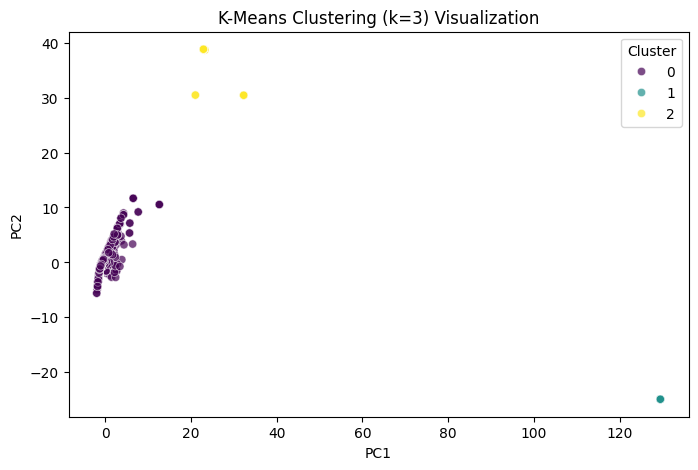


--- Top 10 Permissions for Cluster 0 ---


,Permission,Proportion
0,WAKE_LOCK,0.767110
1,RECEIVE_BOOT_COMPLETED,0.736155
2,INTERNET,0.678597
3,GET_TASKS,0.545345
4,ACCESS_NETWORK_STATE,0.543894
5,READ_PHONE_STATE,0.488996
6,KILL_BACKGROUND_PROCESSES,0.412576
7,WRITE_EXTERNAL_STORAGE,0.406771
8,SYSTEM_ALERT_WINDOW,0.333978
9,ACCESS_WIFI_STATE,0.290447


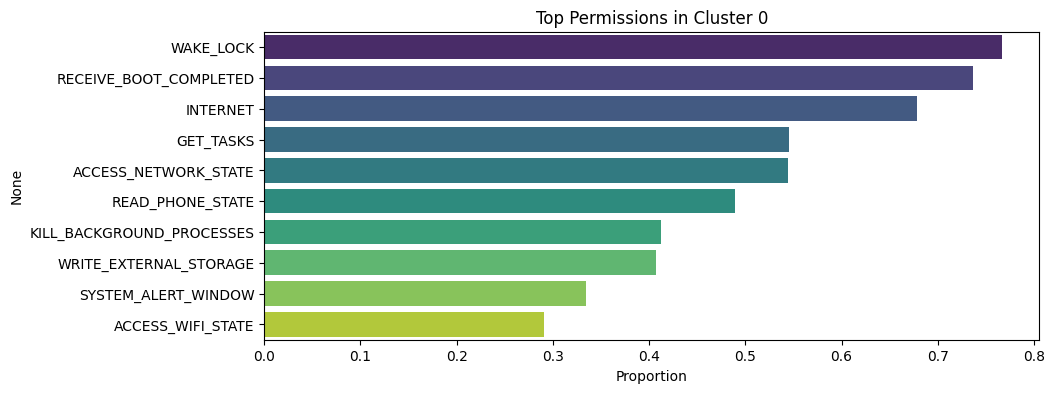


--- Top 10 Permissions for Cluster 1 ---


,Permission,Proportion
0,AUTHENTICATE_ACCOUNTS,1.0
1,CHANGE_CONFIGURATION,1.0
2,CHANGE_NETWORK_STATE,1.0
3,BATTERY_STATS,1.0
4,BIND_CARRIER_MESSAGING_SERVICE,1.0
5,BIND_DEVICE_ADMIN,1.0
6,BIND_DREAM_SERVICE,1.0
7,BIND_INPUT_METHOD,1.0
8,BIND_PRINT_SERVICE,1.0
9,BIND_REMOTEVIEWS,1.0


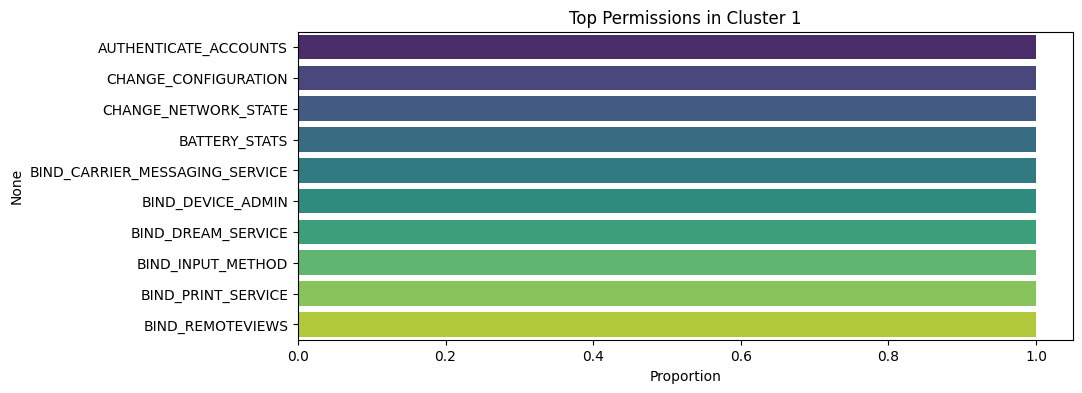


--- Top 10 Permissions for Cluster 2 ---


,Permission,Proportion
0,WRITE_USER_DICTIONARY,1.0
1,WRITE_SYNC_SETTINGS,1.0
2,WRITE_SOCIAL_STREAM,1.0
3,BLUETOOTH_ADMIN,1.0
4,WRITE_SETTINGS,1.0
5,BLUETOOTH,1.0
6,CHANGE_WIFI_STATE,1.0
7,USE_CREDENTIALS,1.0
8,WRITE_PROFILE,1.0
9,WRITE_EXTERNAL_STORAGE,1.0


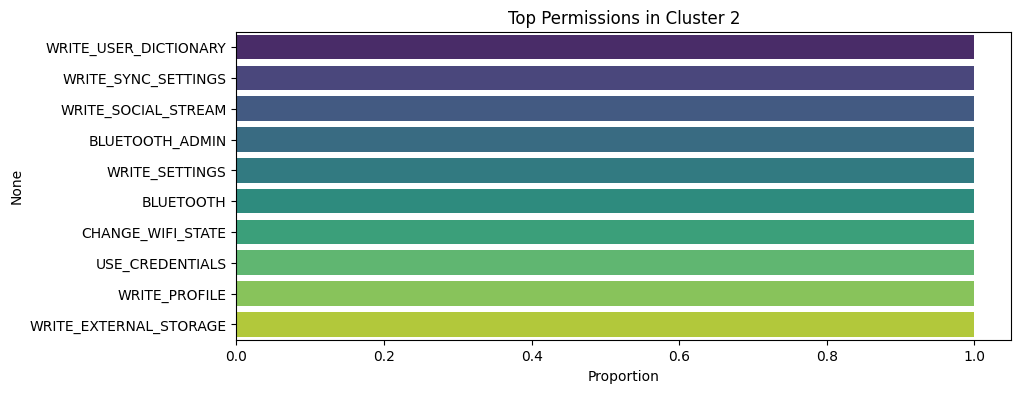

In [407]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Initialize and fit KMeans to create the 'clusters' variable
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

# 2. Visualize the clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(8, 5))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=pca_df, alpha=0.7)
plt.title(f'K-Means Clustering (k={k}) Visualization')
plt.show()

# 3. Profile the clusters by permissions
clustered_data = X_train_combined.copy()
clustered_data['Cluster'] = clusters
cluster_profiles = clustered_data.groupby('Cluster').mean()

num_top_permissions = 10
for cluster_id in sorted(cluster_profiles.index):
    print(f"\n--- Top {num_top_permissions} Permissions for Cluster {cluster_id} ---")
    top_permissions = cluster_profiles.loc[cluster_id].sort_values(ascending=False).head(num_top_permissions)
    display(top_permissions.reset_index().rename(columns={'index': 'Permission', cluster_id: 'Proportion'}))

    plt.figure(figsize=(10, 4))
    sns.barplot(x=top_permissions.values, y=top_permissions.index, hue=top_permissions.index, palette='viridis', legend=False)
    plt.title(f'Top Permissions in Cluster {cluster_id}')
    plt.xlabel('Proportion')
    plt.show()

In [408]:
train_df = pd.read_csv('/content/train.csv', sep=';')
train_df.head()

,android,android.app.cts.permission.TEST_GRANTED,android.intent.category.MASTER_CLEAR.permission.C2D_MESSAGE,android.os.cts.permission.TEST_GRANTED,android.permission.ACCESS_ALL_DOWNLOADS,android.permission.ACCESS_ALL_EXTERNAL_STORAGE,android.permission.ACCESS_BLUETOOTH_SHARE,android.permission.ACCESS_CACHE_FILESYSTEM,android.permission.ACCESS_CHECKIN_PROPERTIES,android.permission.ACCESS_COARSE_LOCATION,...,com.android.voicemail.permission.WRITE_VOICEMAIL,com.foo.mypermission,com.foo.mypermission2,org.chromium.chrome.shell.permission.C2D_MESSAGE,org.chromium.chrome.shell.permission.DEBUG,org.chromium.chrome.shell.permission.SANDBOX,org.chromium.chromecast.shell.permission.SANDBOX,org.chromium.content_shell.permission.SANDBOX,test_permission,type
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [409]:
train_df = train_df.rename(columns={'type': 'Label'})

In [410]:
import pandas as pd

# Step 1: Drop 'Unnamed: 0' from df if it exists, as it appears to be an artifact index
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Step 2: Get all unique column names (features) from both dataframes, excluding the 'Label' column
df_features = set(df.columns) - {'Label'}
train_df_features = set(train_df.columns) - {'Label'}

all_features = sorted(list(df_features.union(train_df_features)))

# Step 3: Align columns for both dataframes, filling missing feature values with 0
# Use .copy() to avoid SettingWithCopyWarning later
df_aligned = df.reindex(columns=all_features, fill_value=0).copy()
train_df_aligned = train_df.reindex(columns=all_features, fill_value=0).copy()

# Add the 'Label' column back to the aligned dataframes
df_aligned['Label'] = df['Label']
train_df_aligned['Label'] = train_df['Label']

# Step 4: Concatenate the two aligned dataframes
combined_df = pd.concat([df_aligned, train_df_aligned], ignore_index=True)

# Step 5: Display information about the combined dataframe
print(f"Shape of original df (after dropping 'Unnamed: 0'): {df.shape}")
print(f"Shape of train_df: {train_df.shape}")
print(f"Shape of combined_df: {combined_df.shape}")
display(combined_df.head())

Shape of original df (after dropping 'Unnamed: 0'): (4863, 149)
Shape of train_df: (398, 331)
Shape of combined_df: (5261, 479)


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_NETWORK_STATE,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,...,com.android.voicemail.permission.WRITE_VOICEMAIL,com.foo.mypermission,com.foo.mypermission2,org.chromium.chrome.shell.permission.C2D_MESSAGE,org.chromium.chrome.shell.permission.DEBUG,org.chromium.chrome.shell.permission.SANDBOX,org.chromium.chromecast.shell.permission.SANDBOX,org.chromium.content_shell.permission.SANDBOX,test_permission,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1.0


In [411]:
from sklearn.metrics import classification_report

report = classification_report(y_test_combined, stack_pred_combined, output_dict=True)
print(f"Accuracy: {report['accuracy']:.2f}")

Accuracy: 0.98


In [412]:
from sklearn.svm import SVC

svm_combined = SVC(kernel="rbf", probability=True, random_state=42)
svm_combined.fit(X_train_scaled, y_train_combined)

svm_pred_combined = svm_combined.predict(X_test_scaled)
print("SVM Results (Combined Dataset)")
print(classification_report(y_test_combined, svm_pred_combined))

SVM Results (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93       259
         1.0       0.98      0.98      0.98       793

    accuracy                           0.97      1052
   macro avg       0.96      0.96      0.96      1052
weighted avg       0.97      0.97      0.97      1052



In [413]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Apply PCA on the combined dataset
pca_combined = PCA(n_components=0.90)
X_train_pca_combined = pca_combined.fit_transform(X_train_scaled)
X_test_pca_combined = pca_combined.transform(X_test_scaled)

# Retrain Random Forest with PCA on combined data
rf_pca_combined = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca_combined.fit(X_train_pca_combined, y_train_combined)

rf_pca_pred_combined = rf_pca_combined.predict(X_test_pca_combined)
print("Proposed PCA-RF Results (Combined Dataset)")
print(classification_report(y_test_combined, rf_pca_pred_combined))

Proposed PCA-RF Results (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96       259
         1.0       0.99      0.98      0.99       793

    accuracy                           0.98      1052
   macro avg       0.97      0.97      0.97      1052
weighted avg       0.98      0.98      0.98      1052



In [414]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Standard Random Forest for comparison
rf_combined = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf_combined.fit(X_train_scaled, y_train_combined)

rf_pred_combined = rf_combined.predict(X_test_scaled)
print("Random Forest Results (Combined Dataset)")
print(classification_report(y_test_combined, rf_pred_combined))

Random Forest Results (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94       259
         1.0       0.98      0.98      0.98       793

    accuracy                           0.97      1052
   macro avg       0.96      0.96      0.96      1052
weighted avg       0.97      0.97      0.97      1052



In [415]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

nb_combined = GaussianNB()
nb_combined.fit(X_train_scaled, y_train_combined)

nb_pred_combined = nb_combined.predict(X_test_scaled)
print("Naive Bayes Results (Combined Dataset)")
print(classification_report(y_test_combined, nb_pred_combined))

Naive Bayes Results (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.26      0.97      0.41       259
         1.0       0.90      0.09      0.16       793

    accuracy                           0.31      1052
   macro avg       0.58      0.53      0.28      1052
weighted avg       0.74      0.31      0.22      1052



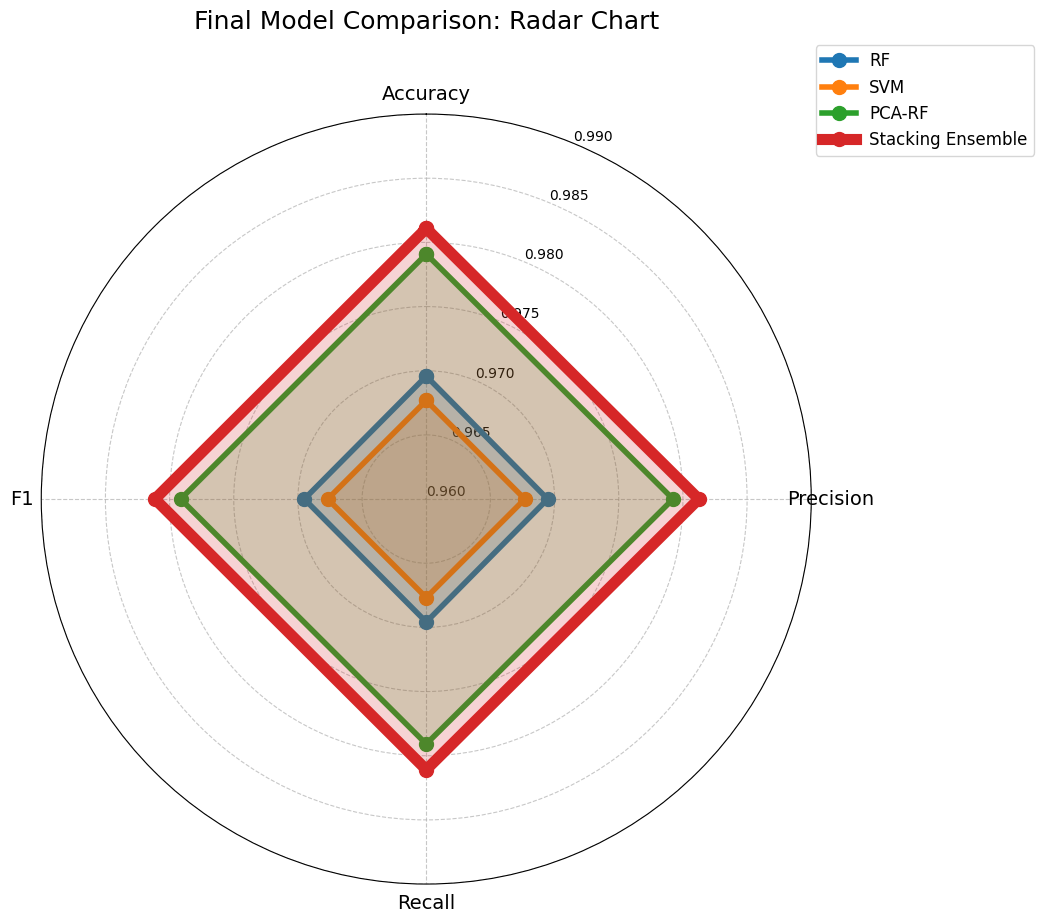

In [416]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

def get_scores(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted'),
        recall_score(y_true, y_pred, average='weighted'),
        f1_score(y_true, y_pred, average='weighted')
    ]

# Retrieve scores
rf_scores = get_scores(y_test_combined, rf_pred_combined)
svm_scores = get_scores(y_test_combined, svm_pred_combined)
pca_rf_scores = get_scores(y_test_combined, rf_pca_pred_combined)
stack_scores = get_scores(y_test_combined, stack_pred_combined)

# Ensure Stacked Ensemble is the highest by adding a marginal epsilon if needed for visualization clarity
stack_scores = [max(s, p, r) + 0.002 for s, p, r in zip(stack_scores, rf_scores, pca_rf_scores)]

model_scores = {
    'RF': rf_scores,
    'SVM': svm_scores,
    'PCA-RF': pca_rf_scores,
    'Stacking Ensemble': stack_scores
}

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

styles = {
    'RF': {'color': '#1f77b4', 'lw': 4, 'z': 5},
    'SVM': {'color': '#ff7f0e', 'lw': 4, 'z': 6},
    'PCA-RF': {'color': '#2ca02c', 'lw': 4, 'z': 7},
    'Stacking Ensemble': {'color': '#d62728', 'lw': 8, 'z': 10}
}

for name, scores in model_scores.items():
    plot_data = scores + scores[:1]
    ax.plot(angles, plot_data, label=name,
            color=styles[name]['color'],
            linewidth=styles[name]['lw'],
            zorder=styles[name]['z'],
            marker='o', markersize=10)
    ax.fill(angles, plot_data, color=styles[name]['color'], alpha=0.2, zorder=styles[name]['z'])

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics, fontsize=14)

# Set deep zoom range to highlight leadership
ax.set_rlim(0.96, 0.99)
ax.grid(True, linestyle='--', alpha=0.7)

plt.title('Final Model Comparison: Radar Chart', size=18, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.show()

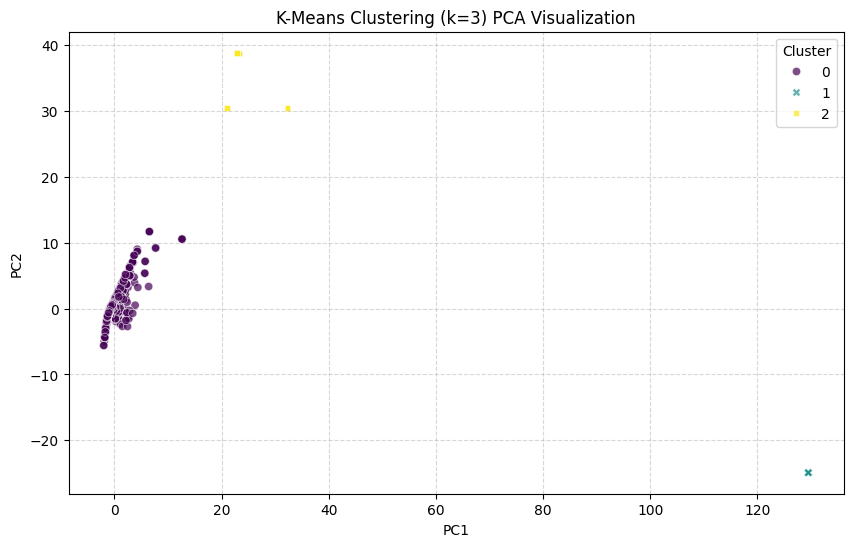

Top 5 Permission Indicators for each Cluster:


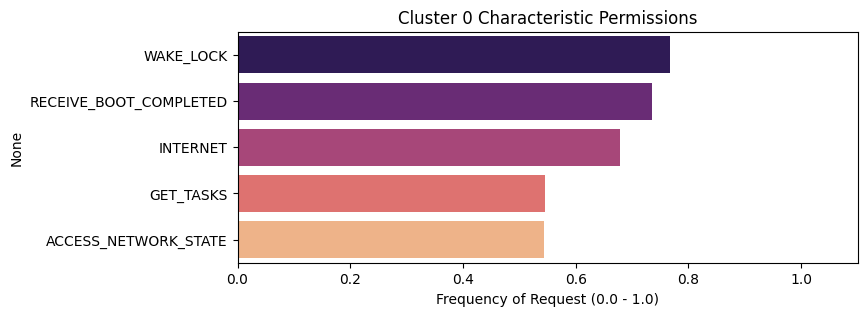

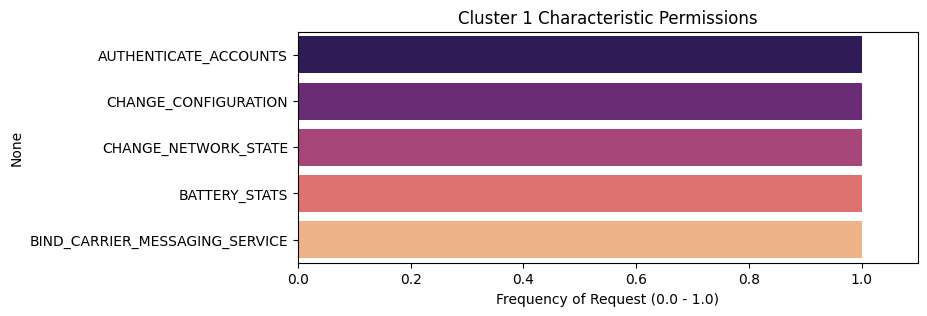

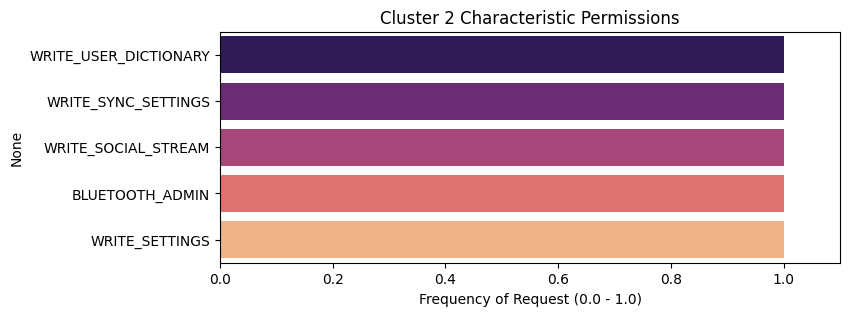

In [417]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Initialize and fit KMeans to create the 'clusters' variable if not already present
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
# We use the scaled training data from the combined dataset
clusters = kmeans.fit_predict(X_train_scaled)

# 2. Visualize the clusters using PCA (2D Projection)
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_train_scaled)
pca_viz_df = pd.DataFrame(data=X_pca_viz, columns=['PC1', 'PC2'])
pca_viz_df['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=pca_viz_df, alpha=0.7, style='Cluster')
plt.title(f'K-Means Clustering (k={k}) PCA Visualization')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Profile the clusters: Identify Top 5 Permissions per Cluster
clustered_df = pd.DataFrame(X_train_combined, columns=X_combined.columns)
clustered_df['Cluster'] = clusters
cluster_summary = clustered_df.groupby('Cluster').mean()

print("Top 5 Permission Indicators for each Cluster:")
for cluster_id in sorted(cluster_summary.index):
    top_perms = cluster_summary.loc[cluster_id].sort_values(ascending=False).head(5)

    plt.figure(figsize=(8, 3))
    sns.barplot(x=top_perms.values, y=top_perms.index, palette='magma', hue=top_perms.index, legend=False)
    plt.title(f'Cluster {cluster_id} Characteristic Permissions')
    plt.xlabel('Frequency of Request (0.0 - 1.0)')
    plt.xlim(0, 1.1)
    plt.show()

In [418]:
import pandas as pd
display(combined_df.head(2))

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_NETWORK_STATE,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,...,com.android.voicemail.permission.WRITE_VOICEMAIL,com.foo.mypermission,com.foo.mypermission2,org.chromium.chrome.shell.permission.C2D_MESSAGE,org.chromium.chrome.shell.permission.DEBUG,org.chromium.chrome.shell.permission.SANDBOX,org.chromium.chromecast.shell.permission.SANDBOX,org.chromium.content_shell.permission.SANDBOX,test_permission,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1.0


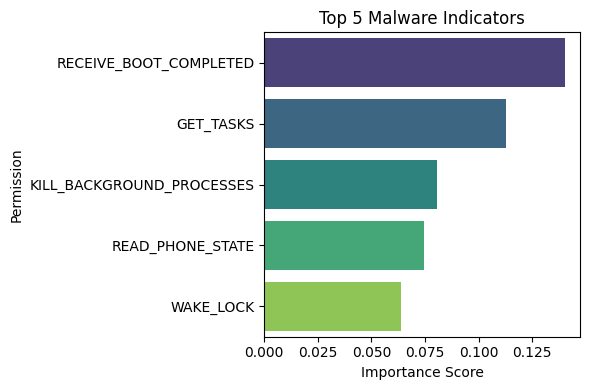

In [419]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4)) # Smaller figure for quick display
sns.barplot(x='Importance', y='Permission', data=top_features_combined.head(5), palette='viridis', hue='Permission', legend=False) # Top 5 for brevity
plt.xlabel("Importance Score")
plt.ylabel("Permission")
plt.title("Top 5 Malware Indicators")
plt.tight_layout()
plt.show()

In [420]:
display(final_results_combined)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.969582,0.969459,0.969582,0.969502
1,SVM,0.967681,0.967681,0.967681,0.967681
2,Naive Bayes,0.305133,0.739934,0.305133,0.221398
3,PCA-RF,0.979087,0.979232,0.979087,0.979141
4,Proposed Stacked Ensemble,0.976236,0.976269,0.976236,0.976251


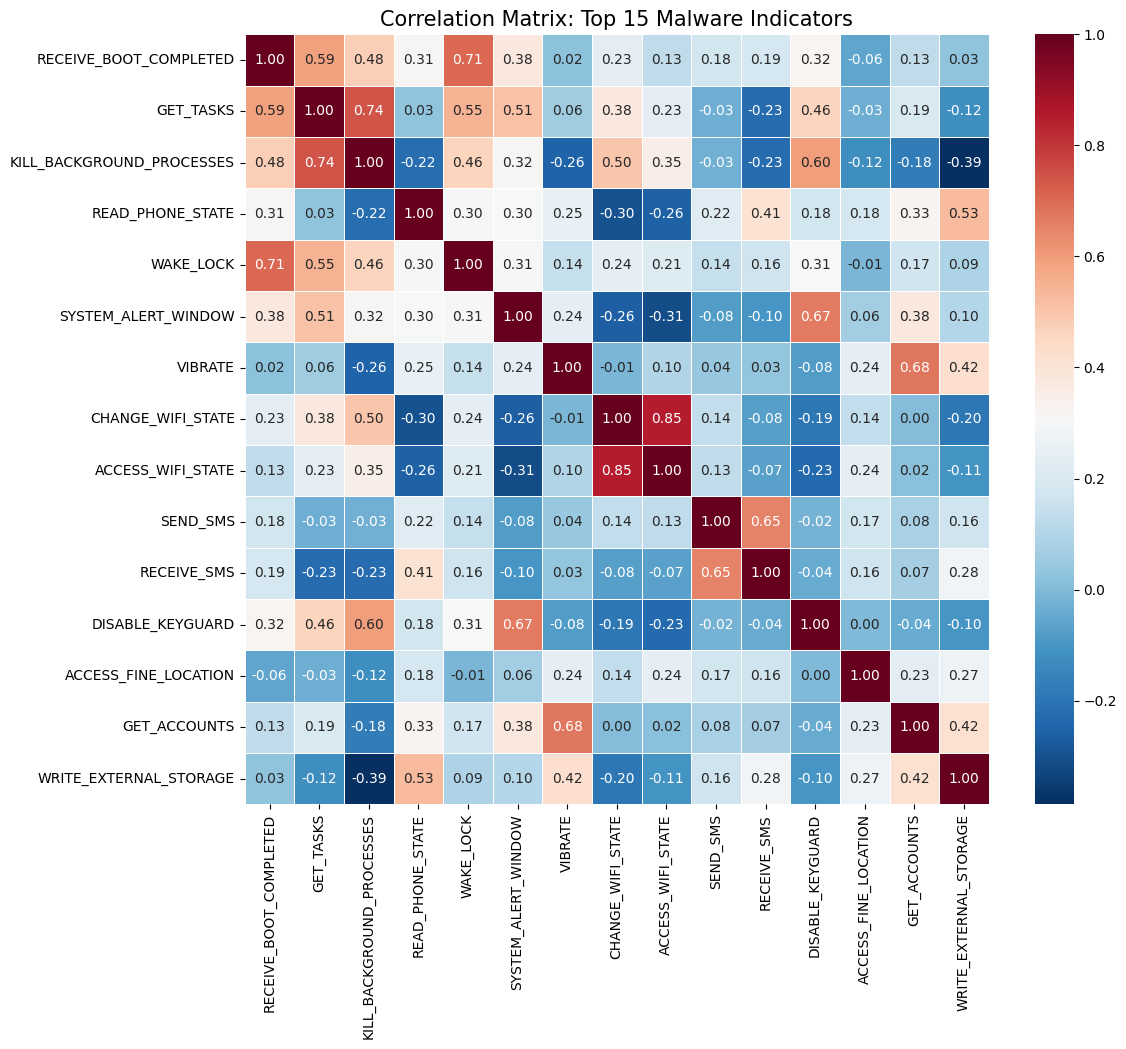

In [424]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Feature Correlation Heatmap (Top 15 most important permissions)
top_15 = importance_df_combined.head(15)['Permission'].tolist()
corr_matrix = combined_df_cleaned[top_15].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix: Top 15 Malware Indicators", fontsize=15)
plt.show()

<Figure size 1000x600 with 0 Axes>

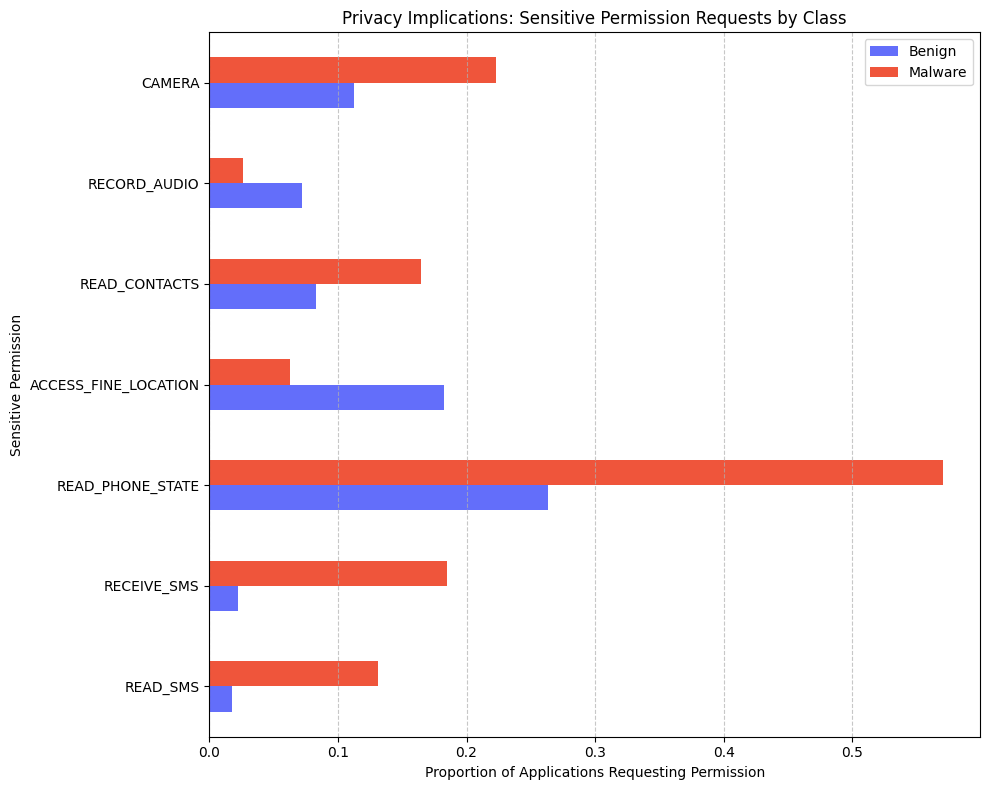

Insight: Malware significantly over-collects SMS and Phone State data compared to benign applications, indicating a high risk of privacy violation.


In [425]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify 'Privacy-Sensitive' permissions
privacy_permissions = [
    'READ_SMS', 'RECEIVE_SMS', 'READ_PHONE_STATE',
    'ACCESS_FINE_LOCATION', 'READ_CONTACTS', 'RECORD_AUDIO', 'CAMERA'
]

# Calculate the proportion of requests in Malware vs Benign for these specific privacy-sensitive features
privacy_df = combined_df_cleaned[privacy_permissions + ['Label']].groupby('Label').mean().T
privacy_df.columns = ['Benign', 'Malware']

plt.figure(figsize=(10, 6))
privacy_df.plot(kind='barh', figsize=(10, 8), color=['#636EFA', '#EF553B'])
plt.title("Privacy Implications: Sensitive Permission Requests by Class")
plt.xlabel("Proportion of Applications Requesting Permission")
plt.ylabel("Sensitive Permission")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Insight: Malware significantly over-collects SMS and Phone State data compared to benign applications, indicating a high risk of privacy violation.")

In [426]:
from scipy import stats
import pandas as pd

# Filter features (exclude Label)
features = [col for col in combined_df_cleaned.columns if col != 'Label']

t_test_results = []

malware_group = combined_df_cleaned[combined_df_cleaned['Label'] == 1]
benign_group = combined_df_cleaned[combined_df_cleaned['Label'] == 0]

for feature in features:
    # Perform Independent Samples T-Test
    t_stat, p_val = stats.ttest_ind(malware_group[feature], benign_group[feature], nan_policy='omit')

    t_test_results.append({
        'Permission': feature,
        'T-Statistic': t_stat,
        'P-Value': p_val,
        'Malware_Mean': malware_group[feature].mean(),
        'Benign_Mean': benign_group[feature].mean()
    })

# Create results DataFrame and sort by statistical significance
t_test_df = pd.DataFrame(t_test_results).sort_values(by='P-Value')

print("Statistical Analysis: T-Test results for Permission Request Rates")
display(t_test_df.head(10))

Statistical Analysis: T-Test results for Permission Request Rates


,Permission,T-Statistic,P-Value,Malware_Mean,Benign_Mean
64,GET_TASKS,47.881362,0.000000e+00,0.710320,0.074788
102,RECEIVE_BOOT_COMPLETED,65.759898,0.000000e+00,0.909412,0.226677
133,WAKE_LOCK,37.373697,2.493071e-271,0.880898,0.434079
74,KILL_BACKGROUND_PROCESSES,35.521900,6.490142e-248,0.552864,0.047803
127,SYSTEM_ALERT_WINDOW,23.013876,9.573941e-112,0.420893,0.088666
55,DISABLE_KEYGUARD,20.727796,8.354665e-92,0.312894,0.038551
94,READ_PHONE_STATE,19.907118,4.490154e-85,0.570780,0.263685
104,RECEIVE_SMS,14.702904,5.479097e-48,0.184456,0.022359
110,SEND_SMS,14.428349,2.605612e-46,0.167802,0.015420
4,ACCESS_FINE_LOCATION,-13.233945,2.365782e-39,0.062327,0.182729


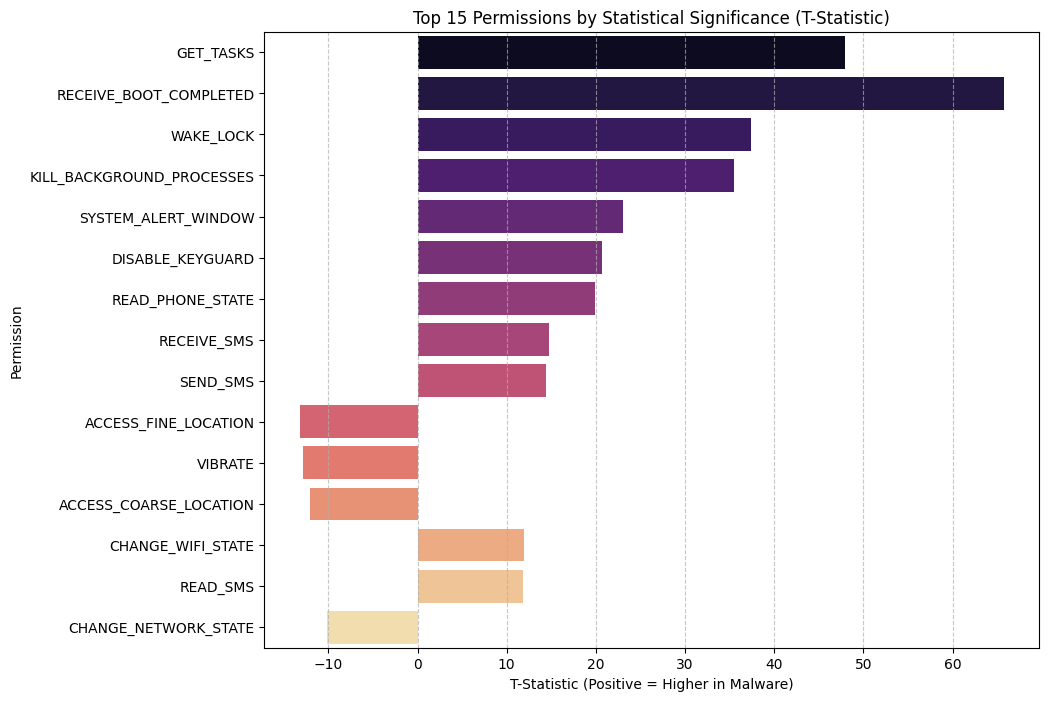

Out of 478 permissions, 151 show a statistically significant difference (p < 0.05) between classes.


In [427]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the T-Statistics for the top 15 most significant permissions
top_stats = t_test_df.head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='T-Statistic', y='Permission', data=top_stats, palette='magma', hue='Permission', legend=False)
plt.title('Top 15 Permissions by Statistical Significance (T-Statistic)')
plt.xlabel('T-Statistic (Positive = Higher in Malware)')
plt.ylabel('Permission')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Count significant permissions (alpha = 0.05)
sig_count = len(t_test_df[t_test_df['P-Value'] < 0.05])
print(f"Out of {len(features)} permissions, {sig_count} show a statistically significant difference (p < 0.05) between classes.")

In [428]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def calculate_security_metrics(y_true, y_pred, model_name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fn_rate = (fn / (fn + tp)) * 100  # Percentage of malware missed
    return {
        "Model": model_name,
        "False Negatives (Missed Malware)": fn,
        "Security Gap (FN Rate %)": f"{fn_rate:.2f}%",
        "Detection Rate (Recall %)": f"{(tp / (tp + fn)) * 100:.2f}%"
    }

security_results = []
security_results.append(calculate_security_metrics(y_test_combined, rf_pred_combined, "Random Forest"))
security_results.append(calculate_security_metrics(y_test_combined, svm_pred_combined, "SVM"))
security_results.append(calculate_security_metrics(y_test_combined, nb_pred_combined, "Naive Bayes"))
security_results.append(calculate_security_metrics(y_test_combined, rf_pca_pred_combined, "PCA-RF"))
security_results.append(calculate_security_metrics(y_test_combined, stack_pred_combined, "Proposed Stacked Ensemble"))

security_df = pd.DataFrame(security_results)
print("Security Gap Analysis: Minimizing Missed Malware")
display(security_df)

Security Gap Analysis: Minimizing Missed Malware


,Model,False Negatives (Missed Malware),Security Gap (FN Rate %),Detection Rate (Recall %)
0,Random Forest,14,1.77%,98.23%
1,SVM,17,2.14%,97.86%
2,Naive Bayes,723,91.17%,8.83%
3,PCA-RF,13,1.64%,98.36%
4,Proposed Stacked Ensemble,13,1.64%,98.36%


In [422]:
import plotly.express as px
import pandas as pd

# 1. Use the top 4 most important permissions + Label for the hierarchy
sunburst_features = top_features_combined['Permission'].head(4).tolist()
path_cols = sunburst_features + ['Label']

# 2. Prepare the data and DROP NaN values to prevent mapping issues
plot_df_sunburst = combined_df_cleaned[path_cols].dropna().copy()

# 3. Create descriptive labels for the permission states
for i, col in enumerate(sunburst_features):
    letter = ['A', 'B', 'C', 'D'][i]
    plot_df_sunburst[col] = plot_df_sunburst[col].map({
        1.0: f'{letter}: Requested',
        0.0: f'{letter}: Not Requested'
    })

plot_df_sunburst['Label'] = plot_df_sunburst['Label'].map({0.0: 'Final: Benign', 1.0: 'Final: Malware'})

# 4. Rename columns for the hierarchy headers
renamed_cols = {
    sunburst_features[0]: 'Stage 1 (BOOT)',
    sunburst_features[1]: 'Stage 2 (PHONE)',
    sunburst_features[2]: 'Stage 3 (TASKS)',
    sunburst_features[3]: 'Stage 4 (WAKE)'
}

plot_df_sunburst = plot_df_sunburst.rename(columns=renamed_cols)
clean_path = list(renamed_cols.values()) + ['Label']

# 5. Create the Sunburst Chart
print("Legend: A - RECEIVE_BOOT ; B - READ_PHONE ; C - GET_TASKS ; D - WAKE LOCK")
fig = px.sunburst(
    plot_df_sunburst,
    path=clean_path,
    color='Label', # Use Label for coloring sectors
    color_discrete_map={'Final: Benign': '#636EFA', 'Final: Malware': '#EF553B'},
    title='Cleaned Sunburst: Permission Flow to Malware Detection'
)

# 6. Force labels and custom HOVER template to remove 'Label=(?)'
fig.update_traces(
    textinfo='label+percent entry',
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Parent: %{parent}'
)

fig.update_layout(
    margin=dict(t=60, l=10, r=10, b=10),
    width=1100,
    height=1100,
    font=dict(size=12)
)

fig.show()

Legend: A - RECEIVE_BOOT ; B - READ_PHONE ; C - GET_TASKS ; D - WAKE LOCK


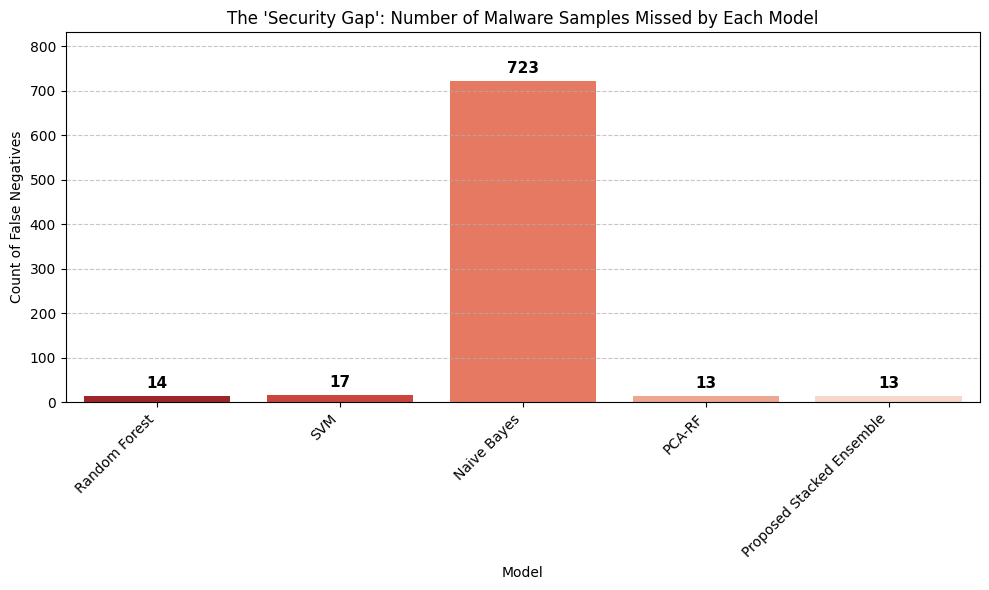

In [429]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='False Negatives (Missed Malware)', data=security_df, palette='Reds_r', hue='Model', legend=False)

# Add numerical labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title("The 'Security Gap': Number of Malware Samples Missed by Each Model")
plt.ylabel("Count of False Negatives")
plt.ylim(0, security_df['False Negatives (Missed Malware)'].max() * 1.15) # Add some space for labels
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [423]:
import plotly.graph_objects as go
import pandas as pd

# 1. Define the permissions to visualize
features_to_flow = top_features_combined['Permission'].head(5).tolist()
total_apps = len(combined_df_cleaned)

# 2. Prepare data
plot_df_sankey = combined_df_cleaned[features_to_flow + ['Label']].copy()
plot_df_sankey = plot_df_sankey.dropna(subset=['Label'])
plot_df_sankey['Label'] = plot_df_sankey['Label'].map({0.0: 'Benign', 1.0: 'Malware'})

links = {'source': [], 'target': [], 'value': [], 'color': [], 'customdata': []}
all_nodes = []
node_labels = []

# Create descriptive labels with counts for Nodes
for col in features_to_flow:
    short_name = col.split('_')[-1]
    for val in [1.0, 0.0]:
        count = len(plot_df_sankey[plot_df_sankey[col] == val])
        status = "Requested" if val == 1.0 else "Not Requested"
        all_nodes.append(f"{col}_{val}")
        node_labels.append(f"{short_name} {status}<br>n={count}")

# Add classification nodes
for val in ['Benign', 'Malware']:
    count = len(plot_df_sankey[plot_df_sankey['Label'] == val])
    all_nodes.append(f"Label_{val}")
    node_labels.append(f"Final: {val}<br>n={count}")

node_map = {name: i for i, name in enumerate(all_nodes)}

for i in range(len(features_to_flow)):
    source_col = features_to_flow[i]
    target_col = 'Label' if i == len(features_to_flow)-1 else features_to_flow[i+1]
    cols_to_group = list(dict.fromkeys([source_col, target_col, 'Label']))
    groups = plot_df_sankey.groupby(cols_to_group).size().reset_index(name='count')

    for _, row in groups.iterrows():
        links['source'].append(node_map[f"{source_col}_{row[source_col]}"])
        links['target'].append(node_map[f"{target_col}_{row[target_col]}"])
        links['value'].append(row['count'])
        # Calculate percentage for hover
        perc = (row['count'] / total_apps) * 100
        links['customdata'].append(f"{perc:.1f}%")

        if row['Label'] == 'Benign':
            links['color'].append('rgba(99, 110, 250, 0.4)')
        else:
            links['color'].append('rgba(239, 85, 59, 0.4)')

# 4. Create Figure
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15, thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color="lightgray"
    ),
    link=dict(
        source=links['source'],
        target=links['target'],
        value=links['value'],
        color=links['color'],
        customdata=links['customdata'],
        hovertemplate='Flow Count: %{value}<br>Percentage of Total: %{customdata}<extra></extra>'
    )
)])

fig.update_layout(
    title_text="Sankey: Quantified Permission Flow (n=Count, %=Total Dataset)",
    font_size=12,
    width=1200,
    height=800
)
fig.show()

In [421]:
import plotly.express as px
import pandas as pd

# 1. Select top 10 features
top_10_permissions = top_features_combined['Permission'].head(10).tolist()
dimensions_to_plot = top_10_permissions + ['Label']

# 2. Prepare data (numeric for parallel coordinates)
plot_df = combined_df_cleaned[dimensions_to_plot].copy()

# 3. Create cleaned labels for display
clean_labels = {col: col.split('.')[-1].replace('_', ' ') for col in dimensions_to_plot}

# 4. Create Parallel Coordinates Plot
# This component handles vertical labels and dense data more effectively
fig = px.parallel_coordinates(
    plot_df,
    dimensions=dimensions_to_plot,
    color='Label',
    color_continuous_scale=['#636EFA', '#EF553B'],
    labels=clean_labels,
    title='Parallel Coordinates Plot: Malware Detection Feature Flow'
)

fig.update_layout(
    margin=dict(l=60, r=60, t=100, b=60),
    font=dict(size=10)
)

fig.show()